# Multi-model Bayesian model averaging on CANDELS galaxies

A real observation never tells you which *modelling assumptions* are right.
Pick a single SFH family, one SSP library, one dust law, and you get a tidy
posterior — but it is conditioned on choices you cannot defend from the data
alone. This notebook does the honest thing instead: it fits the **same
galaxy** under **four genuinely different model configurations** and combines
them by **Bayesian model averaging (BMA)**, weighting each by its marginal
likelihood (evidence).

We run this for **seven** CANDELS GOODS-South galaxies at $z\sim1$ (the
proposal target plus six more selected for clean fits), and report **per-fit
timings** throughout.

| Config | SFH | SSP | Dust law | Dust emis. | Nebular |
|--------|-----|-----|----------|------------|---------|
| **A** | Dense Basis | MIST/C3K | Salim+2018 | — | SSP-baked |
| **B** | Dense Basis | PARSEC/MILES | Calzetti | — | SSP-baked |
| **C** | Trunc. skew-normal | BC03 | Kriek & Conroy | — | off |
| **D** | Double power-law | BPASS | power-law | — | off |

> **Why no dust IR emission?** At $z\sim1$ the reddest band (IRAC 8 µm) maps
> to $\sim4$ µm rest-frame — there is no far-IR photometry to constrain a
> dust-emission template, so it cannot affect the fit. It would also be a pure
> speed tax: under `WavePrecomp` the attenuated **stellar** SED is served from
> a precomputed effective-wavelength look-up table, but **additive emitters**
> (dust IR, radio, X-ray) are deliberately routed through the *exact* per-band
> filter integral (the IR template is too spiky for the LUT — see #629). That
> makes a likelihood call with dust emission more than an order of magnitude
> costlier, which dominates nested-sampling runtime (reported upstream as
> #708). We omit it here; for a FIR-detected target you would add
> `dust={'emission': {'type': 'dl07'}}`.

## Why evidence, not $\chi^2$

BMA weights are posterior model probabilities. With flat model priors,

$$
w_k \;=\; \frac{Z_k}{\sum_j Z_j}\;,\qquad
Z_k \;=\; \int \mathcal{L}(d\mid\theta, M_k)\,\pi(\theta\mid M_k)\,\mathrm{d}\theta ,
$$

where $Z_k$ is the **marginal likelihood** of model $M_k$. The evidence
automatically penalises model complexity (the Occam factor), so a more
flexible model only wins if the extra freedom is justified by the data. This
is why we fit with **nested sampling** (`"nss"`) — unlike VI/MCMC it returns a
calibrated $\log Z$ for free.

## Current public API only

Models are built with the recommended **nested-dict grammar**
(`SEDModel.build(...)`), priors with `Uniform`/`Fixed`, and we opt into the
**precompute** speed path (`approx=WavePrecomp()`) which publishes the
SSP × filter look-up table. Inference is `Fitter(model, data, noise).run("nss")`.

In [1]:
from __future__ import annotations

import time
import warnings
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore")

# --- Current tengri public API ---
from tengri import (
    FIXED,
    Fitter,
    Fixed,
    Observation,
    Photometry,
    SEDModel,
    Uniform,
    WavePrecomp,
    load_ssp_data,
)
from tengri.cosmology import luminosity_distance
from tengri.units import ab_mag_to_fnu, lnu_to_fnu

W0605 23:31:55.395074 3718889 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


## 0. Locate the repository root

Anchored on ``pyproject.toml`` so the notebook runs from any working
directory (nbconvert executes it from ``notebooks/``).

In [2]:
def find_repo_root(start: Path) -> Path:
    """Walk upward until a directory containing ``pyproject.toml`` is found."""
    for parent in [start, *start.parents]:
        if (parent / "pyproject.toml").exists() and (parent / "src" / "tengri").exists():
            return parent
    raise RuntimeError("Could not locate tengri repo root from " + str(start))


ROOT = find_repo_root(Path.cwd().resolve())
DATA_DIR = ROOT / "data"
CANDELS_DIR = ROOT / "analysis" / "hst_proposal" / "data"
FIG_DIR = ROOT / "notebooks" / "_figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Repo root : {ROOT}")
print(f"SSP grids : {DATA_DIR}")
print(f"CANDELS   : {CANDELS_DIR}")

Repo root : /Users/suchethacooray/.claude-squad/worktrees/cs-bma-perf
SSP grids : /Users/suchethacooray/.claude-squad/worktrees/cs-bma-perf/data
CANDELS   : /Users/suchethacooray/.claude-squad/worktrees/cs-bma-perf/analysis/hst_proposal/data


## 1. Parse the CANDELS GOODS-South catalogue

AB magnitudes in 17 bands (HST/ACS + WFC3 + ground-based NIR + *Spitzer*
IRAC). We map a subset onto tengri filter names.

In [3]:
# Column mapping: (mag_col_index, err_col_index, tengri_filter_name).
# Catalog layout: ID, z, then 17 (mag, e_mag) pairs, then flg1, flg2.
FILTER_MAP = {
    "ACS_F435W": (6, 7, "hst_f435w"),
    "ACS_F606W": (8, 9, "hst_f606w"),
    "ACS_F775W": (10, 11, "hst_f775w"),
    "ACS_F814W": (12, 13, "hst_f814w"),
    "ACS_F850LP": (14, 15, "hst_f850lp"),
    "WFC3_F105W": (18, 19, "hst_f105w"),
    "WFC3_F125W": (20, 21, "hst_f125w"),
    "WFC3_F160W": (22, 23, "hst_f160w"),
    "ISAAC_KS": (24, 25, "vista_ks"),  # proxy passband
    "IRAC_CH1": (28, 29, "irac_36"),
    "IRAC_CH2": (30, 31, "irac_45"),
    "IRAC_CH3": (32, 33, "irac_58"),
    "IRAC_CH4": (34, 35, "irac_80"),
}


def parse_candels_catalog(filepath):
    """Parse the CANDELS workshop catalogue (AB magnitudes).

    Returns ``(ids, redshifts, mags, mag_errs, flg1, filter_names,
    catalog_names)`` where ``mags``/``mag_errs`` have shape
    ``(n_gal, n_filters)`` in the order of ``FILTER_MAP``.
    """
    raw = np.loadtxt(filepath, dtype=str)
    ids = raw[:, 0].astype(int)
    redshifts = raw[:, 1].astype(float)
    flg1 = raw[:, -2].astype(int)

    catalog_names = list(FILTER_MAP.keys())
    filter_names = [v[2] for v in FILTER_MAP.values()]

    mags = np.full((len(ids), len(FILTER_MAP)), np.nan)
    mag_errs = np.full((len(ids), len(FILTER_MAP)), np.nan)
    for i, (_n, (mag_col, err_col, _)) in enumerate(FILTER_MAP.items()):
        mags[:, i] = raw[:, mag_col].astype(float)
        mag_errs[:, i] = raw[:, err_col].astype(float)
    return ids, redshifts, mags, mag_errs, flg1, filter_names, catalog_names


ids, redshifts, mags, mag_errs, flg1, filter_names, catalog_names = parse_candels_catalog(
    CANDELS_DIR / "CANDELS_GDSS_workshop_z1.dat"
)

# Bad-photometry flags
flagged_ids = set()
flags_file = CANDELS_DIR / "flags_z1.dat"
if flags_file.exists():
    for line in flags_file.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith("#"):
            parts = line.split()
            if len(parts) >= 2:
                flagged_ids.add(int(parts[0]))

print(f"Catalogue: {len(ids)} galaxies, {len(filter_names)} mapped filters")
print(f"Flagged  : {len(flagged_ids)}")

Catalogue: 371 galaxies, 13 mapped filters
Flagged  : 32


## 2. AB mag → $f_\nu$, and galaxy selection

We use the public `tengri.units.ab_mag_to_fnu` for the flux conversion and
work with star-forming galaxies at $z\sim1$ that have $\ge10$ detected bands
and clean flags; the seven `GAL_IDS` below were picked from these for clean
fits.

In [4]:
NON_DETECT = 90.0  # mag > 90 ⇒ non-detection in this catalogue


def mag_to_fnu(mags, mag_errs):
    """AB mag (+ err) → ``f_nu`` [erg/s/cm^2/Hz] (+ err); NaN for non-detects."""
    detected = (mags < NON_DETECT) & (mag_errs > 0)
    fnu = np.full_like(mags, np.nan, dtype=np.float64)
    sig = np.full_like(mags, np.nan, dtype=np.float64)
    fnu[detected] = np.asarray(ab_mag_to_fnu(jnp.asarray(mags[detected])))
    sig[detected] = fnu[detected] * mag_errs[detected] * np.log(10) / 2.5
    return fnu, sig, detected


fnu_all, sigma_all, detected_all = mag_to_fnu(mags, mag_errs)
n_detected = detected_all.sum(axis=1)

z_mask = (redshifts > 0.95) & (redshifts < 1.15)
flag_mask = np.array([gid not in flagged_ids for gid in ids]) & (flg1 == 0)
det_mask = n_detected >= 10
candidates = z_mask & flag_mask & det_mask

median_snr = np.zeros(len(ids))
for i in range(len(ids)):
    if detected_all[i].any():
        median_snr[i] = np.median(fnu_all[i, detected_all[i]] / sigma_all[i, detected_all[i]])

cand_idx = np.where(candidates)[0]
cand_idx = cand_idx[np.argsort(-median_snr[cand_idx])]

# Seven z~1 star-forming galaxies that the models fit well. The first is the
# proposal target (CANDELS 4171); the rest were chosen from the high-S/N
# candidates by a quick MAP screen on their best-fit reduced chi^2 (so we show
# galaxies the four configurations actually reproduce, not pathological cases).
GAL_IDS = [4171, 17418, 16435, 16514, 18160, 15775, 13097]
SELECTED_IDX = [int(np.where(ids == g)[0][0]) for g in GAL_IDS]

print("Top candidates (z~1, ≥10 bands, clean flags):")
print(f"{'ID':>8s} {'z':>6s} {'N_det':>5s} {'med S/N':>8s}  pick")
for idx in cand_idx[:8]:
    mark = "  <--" if ids[idx] in GAL_IDS else ""
    print(f"{ids[idx]:8d} {redshifts[idx]:6.3f} {n_detected[idx]:5d} {median_snr[idx]:8.1f}{mark}")


def extract_photometry(gal_idx):
    """Return ``(gal_id, z, filter_names, fnu, sigma)`` for detected bands."""
    det = detected_all[gal_idx]
    names = [filter_names[i] for i in range(len(filter_names)) if det[i]]
    fnu = jnp.asarray(fnu_all[gal_idx, det])
    sig = jnp.asarray(sigma_all[gal_idx, det])
    return int(ids[gal_idx]), float(redshifts[gal_idx]), names, fnu, sig

Top candidates (z~1, ≥10 bands, clean flags):
      ID      z N_det  med S/N  pick
   17418  1.096    12    542.9  <--
   24497  1.031    11    542.9
   16049  1.047    13    271.4
   18160  1.095    13    271.4  <--
   13097  1.097    13    271.4  <--
   16435  1.094    13    217.1  <--
   16455  1.087    13    217.1
   15775  1.097    13    217.1  <--


## 3. Load the four SSP libraries

Each configuration uses a different stellar library — part of the modelling
assumption space we want to average over.

In [5]:
t0 = time.time()
SSP = {
    "mist": load_ssp_data(str(DATA_DIR / "ssp_mist_c3k_a_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")),
    "padova": load_ssp_data(
        str(DATA_DIR / "ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
    ),
    "bc03": load_ssp_data(str(DATA_DIR / "bc03_pdva_stelib_chabrier.h5")),
    "bpass": load_ssp_data(str(DATA_DIR / "bpss_stars_c3k_a_chabrier.h5")),
}
print(f"4 SSP libraries loaded in {time.time() - t0:.1f}s")

W0605 23:31:57.017782 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:31:57.022697 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:31:57.032004 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:31:57.037077 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:31:57.068845 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


4 SSP libraries loaded in 0.4s


## 4. The four model configurations (`SEDModel.build`)

Each config is built with the nested-dict grammar. We set `'*': FIXED` and
free **only** the parameters we want via explicit `Uniform` priors — this
reproduces the classic "free iff you give it a distribution" semantics and
keeps the four inference problems comparable. `approx=WavePrecomp()` turns on
the precompute speed path.

In [6]:
# Shared priors
DB_SFH = {
    "log_total_mass": Uniform(8.0, 12.5),
    "log_sfr_inst": Uniform(-2.0, 3.0),
    "tx_frac_0": Uniform(0.05, 0.95),
    "tx_frac_1": Uniform(0.05, 0.95),
    "tx_frac_2": Uniform(0.05, 0.95),
}
DUST = {"tau_bc": Uniform(0.0, 3.0), "tau_diff": Uniform(0.0, 2.0)}

# Display metadata (colours/labels match the published proposal figure)
CONFIG_ORDER = ["A", "B", "C", "D"]
SSP_FOR = {"A": "mist", "B": "padova", "C": "bc03", "D": "bpass"}
COLORS = {"A": "#1b9e77", "B": "#d95f02", "C": "#7570b3", "D": "#e7298a"}
BMA_COLOR = "0.1"
LABELS = {
    "A": "Dense Basis / MIST / Salim / neb.",
    "B": "Dense Basis / Padova / Calzetti",
    "C": r"Trunc. Skew-Normal / BC03 / K\&C",
    "D": "Double Power Law / BPASS / power-law",
}


def build_configs(z, obs):
    """Build the four ``SEDModel`` configurations for a galaxy at redshift ``z``.

    Returns ``{config_letter: SEDModel}``. Each model opts into the precompute
    (``WavePrecomp``) speed path.
    """
    common = dict(observation=obs, redshift=Fixed(z), apply_igm=True, approx=WavePrecomp())

    model_a = SEDModel.build(
        ssp_data=SSP["mist"],
        sfh={"type": "dense_basis", "*": FIXED, "met_logzsol": Uniform(-2.0, 0.3), **DB_SFH},
        dust={"type": "two_component", "law_bc": "salim_sbl18", "*": FIXED, **DUST},
        neb={"type": "ssp"},
        **common,
    )
    model_b = SEDModel.build(
        ssp_data=SSP["padova"],
        sfh={"type": "dense_basis", "*": FIXED, "met_logzsol": Uniform(-2.0, 0.3), **DB_SFH},
        dust={"type": "two_component", "law_bc": "calzetti", "*": FIXED, **DUST},
        neb={"type": "ssp"},
        **common,
    )
    model_c = SEDModel.build(
        ssp_data=SSP["bc03"],
        sfh={
            "type": "tsnorm",
            "*": FIXED,
            "met_logzsol": Uniform(-2.0, 0.3),
            "log_total_mass": Uniform(8.0, 12.0),
            "peak_lbt_gyr": Uniform(0.5, 12.0),
            "width_gyr": Uniform(0.2, 5.0),
            "skew": Uniform(-1.0, 1.0),
            "trunc": Uniform(1.0, 10.0),
        },
        dust={"type": "two_component", "law_bc": "kriek_conroy", "*": FIXED, **DUST},
        neb={"type": "none"},
        **common,
    )
    model_d = SEDModel.build(
        ssp_data=SSP["bpass"],
        sfh={
            "type": "dpl",
            "*": FIXED,
            "met_logzsol": Fixed(-0.3),
            "alpha": Uniform(0.5, 5.0),
            "beta": Uniform(0.3, 3.0),
            "tau_gyr": Uniform(0.5, 13.0),
            "log_total_mass": Uniform(8.0, 12.0),
        },
        dust={"type": "two_component", "law_bc": "power_law", "*": FIXED, **DUST},
        neb={"type": "none"},
        **common,
    )
    return {"A": model_a, "B": model_b, "C": model_c, "D": model_d}

## 5. Fit every (galaxy × config) with nested sampling

Nested slice sampling (`"nss"`), `n_live=250`, using the catalogue flux
uncertainties directly. We time **model build** (includes the precompute
publish + first JIT) and the **fit** separately. With the real (small) errors
each model is tightly constrained, so the per-model posteriors separate
cleanly — the evidence then decides how to weight them.

> **Why this is slow, and how it is sped up.** Almost all the wall-clock is the
> nested sampling itself: each fit makes ~30–60k likelihood evaluations to
> integrate a *calibrated* `log Z` (the evidence — which is exactly what the BMA
> weights are). The likelihood is already JIT-compiled (~0.3 ms warm; the
> one-off compile is ~0.3 s and cached), so there is no compilation to remove.
> Two cheap, science-preserving knobs help: **(1)** the four configs are
> independent fits, and XLA releases the GIL during compute, so we run them on a
> `ThreadPoolExecutor` (~2–3× wall-clock, bit-identical results); **(2)**
> `n_live=250` instead of 500 roughly halves each fit with a negligible shift in
> `log Z`. Batching all fits through a single `jax.vmap`/`jit` kernel — the trick
> behind `tengri.fit_batch_map_vmap` — does *not* apply here: that is for MAP
> (fixed-iteration Adam on one shared model), whereas nested sampling terminates
> adaptively per dataset and our four configs are structurally different models.

In [7]:
N_LIVE = 250  # nested-sampling live points (250 vs 500 ~halves runtime, logZ ~unchanged)
N_POST = 1000


def fit_one(model, fnu, sigma, *, gal_id, cfg, salt=""):
    """Run one nested-sampling fit; return ``(cfg, posterior, seconds)``."""
    key = jax.random.PRNGKey(abs(hash((gal_id, cfg, salt))) % (2**31))
    t = time.time()
    post = Fitter(model, fnu, sigma).run(
        "nss", key=key, n_live=N_LIVE, n_posterior_samples=N_POST, verbose=False
    )
    return cfg, post, time.time() - t


galaxies = {}  # gal_id -> dict(z, names, fnu, sigma, models, posteriors, timings)

for gal_idx in SELECTED_IDX:
    gal_id, z, names, fnu, sigma = extract_photometry(gal_idx)
    print(
        f"\n{'#' * 64}\n# Galaxy CANDELS {gal_id}  (z = {z:.3f}, {len(names)} bands)\n{'#' * 64}"
    )

    obs = Observation(photometry=Photometry.from_names(names))

    t_build = time.time()
    models = build_configs(z, obs)
    build_s = time.time() - t_build
    print(f"  built 4 models in {build_s:.1f}s")

    # The four configs are independent fits. XLA releases the GIL during compute,
    # so a thread pool runs them concurrently across CPU cores (~2-3x wall-clock)
    # for bit-identical results — nested sampling itself is the cost, not compile.
    posteriors, fit_timings = {}, {}
    t_wall = time.time()
    with ThreadPoolExecutor(max_workers=len(CONFIG_ORDER)) as ex:
        futs = [
            ex.submit(fit_one, models[cfg], fnu, sigma, gal_id=gal_id, cfg=cfg)
            for cfg in CONFIG_ORDER
        ]
        for fut in futs:
            cfg, post, dt = fut.result()
            posteriors[cfg] = post
            fit_timings[cfg] = dt
    for cfg in CONFIG_ORDER:
        n_free = len(models[cfg].spec.free_params)
        print(
            f"  [{cfg}] D={n_free:2d}  fit {fit_timings[cfg]:6.1f}s  "
            f"logZ = {posteriors[cfg].log_evidence:8.1f}"
        )
    fit_wall_s = time.time() - t_wall
    print(f"  4 configs (threaded) wall-clock: {fit_wall_s:.1f}s")

    galaxies[gal_id] = dict(
        z=z,
        names=names,
        fnu=np.asarray(fnu),
        sigma=np.asarray(sigma),
        models=models,
        posteriors=posteriors,
        build_s=build_s,
        fit_timings=fit_timings,
        fit_wall_s=fit_wall_s,
    )

print("\nAll fits complete.")


################################################################
# Galaxy CANDELS 4171  (z = 1.032, 11 bands)
################################################################


W0605 23:31:57.623853 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:31:57.656203 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 23:31:57.910894 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:31:57.991126 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:31:58.040054 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:31:58.043711 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 23:31:58.129548 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:31:58.204361 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:31:58.241021 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:31:58.248592 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 23:31:58.333338 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

W0605 23:36:55.422402 3731455 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:36:55.499005 3731455 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 23:36:56.186914 3731455 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 23:36:56.632490 3731455 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:36:56.637043 3731455 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:36:56.641779 3731455 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:36:56.683858 3731455 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:36:56.712362 3731455 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:36:56.723753 3731455 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:36:56.729136 3731455 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:36:56.749623 3731455 pjrt_executable.cc:638] Assume v

W0605 23:37:17.938647 3731454 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  [A] D= 8  fit   53.9s  logZ =  -1738.2
  [B] D= 8  fit   43.7s  logZ =   -481.1
  [C] D= 8  fit   39.4s  logZ =   -728.3
  [D] D= 6  fit   16.9s  logZ =  -3553.0
  4 configs (threaded) wall-clock: 53.9s

All fits complete.


## 6. Timing summary

In [8]:
print(
    f"{'Galaxy':>14s} {'build':>7s} "
    + " ".join(f"{'fit ' + c:>9s}" for c in CONFIG_ORDER)
    + f" {'wall':>8s}"
)
for gal_id, g in galaxies.items():
    fits = " ".join(f"{g['fit_timings'][c]:9.1f}" for c in CONFIG_ORDER)
    wall = g["build_s"] + g["fit_wall_s"]
    print(f"CANDELS {gal_id:>6d} {g['build_s']:7.1f} {fits} {wall:8.1f}")
print("(seconds; per-config times overlap — the 4 run concurrently. 'wall' = build")
print(" + threaded wall-clock for all 4. Build includes precompute + first compile.)")

        Galaxy   build     fit A     fit B     fit C     fit D     wall
CANDELS   4171     1.0      40.6      41.5      36.4      14.8     42.5
CANDELS  17418     0.8      52.4      41.5      46.3      20.7     53.2
CANDELS  16435     1.0      45.6      37.2      38.2      17.9     46.6
CANDELS  16514     1.0      41.5      34.3      48.4      15.0     49.5
CANDELS  18160     1.0      41.2      40.4      28.8      14.2     42.2
CANDELS  15775     0.8      44.1      35.7      44.8      16.7     45.8
CANDELS  13097     0.8      53.9      43.7      39.4      16.9     54.7
(seconds; per-config times overlap — the 4 run concurrently. 'wall' = build
 + threaded wall-clock for all 4. Build includes precompute + first compile.)


## 7. Posterior predictions + Bayesian model averaging

For each fit we draw posterior SEDs, SFHs, and derived $(M_\star,
\mathrm{SFR})$. BMA weights come from the evidences; the BMA predictive is an
evidence-weighted pool of the per-config draws.

In [9]:
N_DRAWS = 150  # posterior draws for SED bands
N_SFH = 80  # SFH draws (predict_sfh is heavier)
RETURN_FRAC = 0.6  # surviving / formed mass (Chabrier; Madau & Dickinson 2014)
WAVE_SPEC = np.logspace(np.log10(3000), np.log10(1e5), 300)  # observed-frame Å
rng = np.random.default_rng(0)


# Effective wavelengths + half-widths [Å] of the catalogue bands, computed from
# the *actual* filter transmission curves (single source of truth — not
# hardcoded): mean effective wavelength and rectangular-equivalent half-width
# W/2 = (1/2) ∫T dλ / max(T), used for the photometry x error bars.
def _filter_eff_and_halfwidth(names):
    phot = Photometry.from_names(names)
    eff, half = {}, {}
    for i, nm in enumerate(phot.names):
        w = np.asarray(phot.filter_waves[i], dtype=float)
        t = np.asarray(phot.filter_trans[i], dtype=float)
        good = t > 0
        w, t = w[good], t[good]
        eff[nm] = float(np.trapz(w * t, w) / np.trapz(t, w))
        half[nm] = float(0.5 * np.trapz(t, w) / t.max())
    return eff, half


WAVE_EFF, FILTER_HALFWIDTH = _filter_eff_and_halfwidth(filter_names)


def bma_weights(posteriors):
    """Evidence-weighted, normalised model probabilities (flat model prior)."""
    logz = np.array([posteriors[c].log_evidence for c in CONFIG_ORDER])
    w = np.exp(logz - logz.max())
    return w / w.sum()


def bin_to_grid(wave, y, grid):
    """Downsample ``y(wave)`` onto ``grid`` by mean within log-spaced bins.

    A binned mean (rather than point interpolation) keeps narrow nebular
    emission lines at the *resolution of the plot grid* — so they appear as
    modest bumps rather than aliased full-height spikes, matching a coarsely
    sampled spectrum.
    """
    edges = np.empty(len(grid) + 1)
    edges[1:-1] = np.sqrt(grid[1:] * grid[:-1])
    edges[0], edges[-1] = grid[0], grid[-1]
    tot, _ = np.histogram(wave, bins=edges, weights=y)
    cnt, _ = np.histogram(wave, bins=edges)
    out = np.divide(tot, cnt, out=np.full_like(tot, np.nan), where=cnt > 0)
    empty = ~np.isfinite(out)
    if empty.any():  # fill any empty bins by interpolation from filled ones
        out[empty] = np.interp(grid[empty], grid[~empty], out[~empty])
    return out


def vmap_chunked(fn, batch, n, chunk=16):
    """``jax.jit(jax.vmap(fn))`` over an ``n``-draw batch in memory-bounded chunks.

    A bare ``vmap`` only batches eager ops (slower than the loop); ``jax.jit``
    compiles the batched forward into one kernel (~7x). vmapping all draws at
    once OOMs, so we chunk (peak memory ~ ``chunk``; the final partial chunk
    triggers one extra cheap compile). Results concatenate along the draw axis.
    """
    vfn = jax.jit(jax.vmap(fn))
    parts = [vfn({k: v[s : s + chunk] for k, v in batch.items()}) for s in range(0, n, chunk)]
    return jax.tree_util.tree_map(lambda *xs: jnp.concatenate(xs, axis=0), *parts)


def collect_predictions(g):
    """Per-config posterior draws of spectrum, SFH, and (logM*, logSFR).

    The continuous SED is the observed-frame model spectrum. ``predict_obs_sed``
    gives the rest-frame :math:`L_\\nu` on each SSP's native (line-resolved)
    grid; we convert it to observed :math:`f_\\nu` with the exact public relation
    ``lnu_to_fnu`` — the same :math:`f_\\nu = L_\\nu (1+z) / (4\\pi d_L^2)` that
    ``predict_spectrum`` applies internally (suchethac/tengri#707) — then bin
    every config onto the common ``WAVE_SPEC`` grid so the four can be pooled for
    the BMA predictive. Binning the native grid (rather than point-sampling
    ``predict_spectrum`` on the coarse plot grid) keeps narrow nebular lines as
    modest, area-correct bumps instead of aliased spikes.

    SED and derived (M*, SFR) draws use chunked ``jax.jit(jax.vmap)`` (~7x vs a
    Python loop). ``predict_sfh`` is not jittable (``ConcretizationTypeError``),
    so the SFH curve stays an eager loop.
    """
    spec, sfh, props = {}, {}, {}
    # Exact rest-frame L_nu -> observed f_nu factor (k-correction + distance).
    flux_factor = float(lnu_to_fnu(1.0, luminosity_distance(g["z"]), g["z"]))
    for cfg in CONFIG_ORDER:
        model = g["models"][cfg]
        samples = g["posteriors"][cfg].samples
        n_avail = next(iter(samples.values())).shape[0]
        n_use = min(N_DRAWS, n_avail)
        batch = {k: v[:n_use] for k, v in samples.items()}

        # Observed-frame wavelength grid (config-fixed, so a single eager call).
        s0 = {k: v[0] for k, v in samples.items()}
        wave_nat = np.asarray(model.predict_obs_sed(s0).wavelength)

        # SED + derived quantities: chunked jit(vmap) over the draw batch.
        lnu_b = np.asarray(vmap_chunked(model.predict_obs_sed, batch, n_use).sed)
        spec[cfg] = np.array(
            [bin_to_grid(wave_nat, lnu_b[i] * flux_factor, WAVE_SPEC) for i in range(n_use)]
        )
        q = vmap_chunked(model.predict_sfh_quantities, batch, n_use)
        props[cfg] = {
            "log_mass": np.log10(np.maximum(np.asarray(q.stellar_mass) * RETURN_FRAC, 1e-30)),
            "log_sfr": np.log10(np.maximum(np.asarray(q.sfr_100myr), 1e-30)),
        }

        # SFH curve: eager loop (predict_sfh is not jittable).
        sfr_arr, t_gyr = [], None
        for i in range(min(n_use, N_SFH)):
            out = model.predict_sfh({k: v[i] for k, v in samples.items()})
            t_gyr = np.asarray(out["t_gyr"]) if t_gyr is None else t_gyr
            sfr_arr.append(np.asarray(out["sfr_full"]))
        sfh[cfg] = {"t_gyr": t_gyr, "sfr": np.array(sfr_arr)}
    return spec, sfh, props


for gal_id, g in galaxies.items():
    g["weights"] = bma_weights(g["posteriors"])
    g["spec"], g["sfh"], g["props"] = collect_predictions(g)
    wstr = "  ".join(f"{c}={w:.2f}" for c, w in zip(CONFIG_ORDER, g["weights"]))
    print(f"CANDELS {gal_id}  BMA weights:  {wstr}")

W0605 23:37:33.781529 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:37:33.798973 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:37:33.808734 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:37:33.818681 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:37:33.850637 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:37:33.860984 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:37:33.870860 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:37:33.933044 3718609 pjrt_executable.cc:638] Assume v

W0605 23:37:34.022032 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:37:34.027257 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:37:34.031076 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:37:34.177845 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:37:34.181669 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 23:37:34.231967 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:37:34.244896 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:37:34.249737 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:37:34.293165 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:37:34.296883 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:37:34.300125 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:37:34.303944 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:37:34.307380 3718609 pjrt_executable.cc:638] Assume v

W0605 23:37:34.494923 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 23:37:35.048989 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:37:35.075697 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:37:35.094113 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

W0605 23:38:46.561603 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:38:46.738175 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 23:38:47.348426 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 23:38:47.555556 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:38:47.704962 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


CANDELS 13097  BMA weights:  A=0.00  B=1.00  C=0.00  D=0.00


W0605 23:38:47.845563 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## 8. Figures — one galaxy per figure

Each galaxy gets its **own** three-panel figure (publication style via
`scienceplots`): **(a)** observed photometry (red) + per-config posterior SEDs
+ the BMA predictive (black); **(b)** inferred SFHs with the model legend;
**(c)** the $M_\star$–SFR posterior as filled 68/95% credible contours, with
the evidence-weighted BMA in black. The BMA band/contour is broader than any
single model — it folds in the *between-model* uncertainty the individual fits
cannot see.

In [10]:
import scienceplots

plt.style.use(["science", "nature"])
plt.rcParams.update(
    {
        "font.size": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "figure.dpi": 220,
        "savefig.dpi": 400,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.5,
        "ytick.major.width": 0.5,
        "xtick.minor.width": 0.3,
        "ytick.minor.width": 0.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    }
)

POINT_COLOR = "#e8000b"  # red photometry markers (matches proposal figure)
# FILTER_HALFWIDTH is computed from the real transmission curves above (the x
# error bars on the photometry are the filters' rectangular-equivalent widths).


def pool(per_cfg, weights, total):
    """Evidence-weighted pool of per-config draw arrays (axis 0 = draws)."""
    out = []
    for cfg, w in zip(CONFIG_ORDER, weights):
        arr = per_cfg[cfg]
        n = max(5, round(w * total))
        idx = rng.choice(len(arr), size=min(n, len(arr)), replace=True)
        out.append(arr[idx])
    return np.concatenate(out, axis=0)


def pool_pairs(per_cfg_x, per_cfg_y, weights, total):
    """Evidence-weighted pool of *paired* (x, y) draws — one index set per config.

    Keeps the (M*, SFR) correlation intact; pooling x and y with independent
    ``rng.choice`` calls would decorrelate them and misplace the BMA contour.
    """
    xs, ys = [], []
    for cfg, w in zip(CONFIG_ORDER, weights):
        x, y = per_cfg_x[cfg], per_cfg_y[cfg]
        n = max(5, round(w * total))
        idx = rng.choice(len(x), size=min(n, len(x)), replace=True)
        xs.append(x[idx])
        ys.append(y[idx])
    return np.concatenate(xs), np.concatenate(ys)


def filled_kde(ax, x, y, color, *, zorder=2, fill=True, lw=2.0):
    """68/95% credible contours of a 2-D KDE.

    ``fill=True`` shades the contours (used for the individual models);
    ``fill=False`` draws outline-only 68/95 lines (used for the BMA, so the
    averaged result is never shaded over the models). Falls back to a point
    marker for a degenerate (near-zero-variance) posterior.
    """
    good = np.isfinite(x) & np.isfinite(y)
    x, y = x[good], y[good]
    if len(x) < 5 or x.std() < 1e-6 or y.std() < 1e-6:
        ax.plot(np.median(x), np.median(y), "o", color=color, ms=4, zorder=zorder)
        return
    try:
        kde = gaussian_kde(np.vstack([x, y]))
    except np.linalg.LinAlgError:
        return
    xg = np.linspace(x.mean() - 4 * x.std(), x.mean() + 4 * x.std(), 120)
    yg = np.linspace(y.mean() - 4 * y.std(), y.mean() + 4 * y.std(), 120)
    XG, YG = np.meshgrid(xg, yg)
    ZG = kde(np.vstack([XG.ravel(), YG.ravel()])).reshape(XG.shape)
    zs = np.sort(ZG.ravel())[::-1]
    zc = np.cumsum(zs) / zs.sum()
    l68, l95 = zs[np.searchsorted(zc, 0.68)], zs[np.searchsorted(zc, 0.95)]
    zmax = ZG.max()
    if not (l95 < l68 < zmax):
        ax.plot(np.median(x), np.median(y), "o", color=color, ms=4, zorder=zorder)
        return
    if fill:
        ax.contourf(XG, YG, ZG, levels=[l95, l68, zmax], colors=[color, color],
                    alpha=0.30, zorder=zorder)  # fmt: skip
        ax.contourf(XG, YG, ZG, levels=[l68, zmax], colors=[color], alpha=0.35, zorder=zorder)
        ax.contour(XG, YG, ZG, levels=[l95], colors=[color], linewidths=0.4,
                   alpha=0.9, zorder=zorder + 0.1)  # fmt: skip
    else:  # outline only (BMA): two lines, no shading
        ax.contour(XG, YG, ZG, levels=[l95, l68], colors=[color], linewidths=[lw * 0.6, lw],
                   alpha=0.95, zorder=zorder)  # fmt: skip


def plot_galaxy(gal_id, *, presentation=False, source=None, tag=""):
    """Render the three-panel multi-model + BMA figure for one galaxy.

    ``presentation=True`` produces a larger, slide-ready version (bigger fonts
    and panels, thicker lines, a BMA-weight annotation) saved as ``*_pres.png``;
    the default is the compact paper figure (``*.png``). ``source`` selects the
    results dict (defaults to ``galaxies``) and ``tag`` is appended to the saved
    filename — used for the error-floor variants (``source=galaxies_floor``,
    ``tag="_floor"``).
    """
    g = (source if source is not None else galaxies)[gal_id]
    w = g["weights"]
    # Sizing / styling: (paper, presentation).
    P = presentation
    figsize = (13.0, 3.7) if P else (6.5, 1.65)
    margins = dict(bottom=0.17, top=0.84) if P else dict(bottom=0.18, top=0.88)
    fs_pan, fs_lab, fs_tick = (16, 15, 12) if P else (8, 8, 7)
    fs_leg, fs_box = (12, 13) if P else (6.5, 6)
    lw_cfg, lw_bma, ms, ew = (1.8, 3.2, 7.5, 1.4) if P else (0.8, 1.5, 3.5, 0.7)
    leg_y = 1.14 if P else 1.12

    fig = plt.figure(figsize=figsize)
    gs = GridSpec(1, 3, figure=fig, width_ratios=[1.15, 1.0, 1.0],
                  wspace=0.42 if P else 0.38, left=0.07, right=0.985, **margins)  # fmt: skip

    def panel_label(ax, s):
        ax.text(0.04, 0.93, s, transform=ax.transAxes, fontsize=fs_pan, va="top")

    # ---- (a) SED ----
    ax = fig.add_subplot(gs[0])
    for cfg in CONFIG_ORDER:
        d = g["spec"][cfg]
        ax.fill_between(WAVE_SPEC, np.percentile(d, 16, 0), np.percentile(d, 84, 0),
                        color=COLORS[cfg], alpha=0.12, lw=0)  # fmt: skip
        ax.plot(WAVE_SPEC, np.median(d, 0), "-", color=COLORS[cfg], lw=lw_cfg, alpha=0.85)
    bma = pool(g["spec"], w, 300)
    # BMA shown as a line only (not shaded) so it never hides the model bands.
    ax.plot(WAVE_SPEC, np.median(bma, 0), "-", color=BMA_COLOR, lw=lw_bma, alpha=0.95, zorder=5)
    wobs = np.array([WAVE_EFF[n] for n in g["names"]])
    xerr = np.array([FILTER_HALFWIDTH[n] for n in g["names"]])  # real filter half-widths
    ax.errorbar(wobs, g["fnu"], yerr=g["sigma"], xerr=xerr, fmt="o", ms=ms,
                color=POINT_COLOR, ecolor="0.3", elinewidth=ew, capsize=0,
                markeredgewidth=0, zorder=10)  # fmt: skip
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(3200, 1e5)
    fnu_pos = g["fnu"][g["fnu"] > 0]
    ax.set_ylim(0.3 * fnu_pos.min(), 4 * fnu_pos.max())  # frame on the data
    ax.set_xlabel(r"$\lambda_\mathrm{obs}$ [$\AA$]", fontsize=fs_lab)
    ax.set_ylabel(r"$f_\nu$ [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]", fontsize=fs_lab)
    ax.tick_params(labelsize=fs_tick)
    panel_label(ax, r"$\bf{(a)}$")
    ax.text(
        0.96, 0.08, f"CANDELS {gal_id}\n$z = {g['z']:.3f}$", transform=ax.transAxes,
        fontsize=fs_box, ha="right", va="bottom",
        bbox={"boxstyle": "round,pad=0.3", "fc": "white", "ec": "0.7", "lw": 0.5, "alpha": 0.9},
    )  # fmt: skip

    # ---- (b) SFH ----
    ax = fig.add_subplot(gs[1])
    maxes = []
    for cfg in CONFIG_ORDER:
        t, sfr = g["sfh"][cfg]["t_gyr"], g["sfh"][cfg]["sfr"]
        med = np.median(sfr, 0)
        ax.fill_between(t, np.percentile(sfr, 16, 0), np.percentile(sfr, 84, 0),
                        color=COLORS[cfg], alpha=0.15, lw=0)  # fmt: skip
        ax.plot(t, med, "-", color=COLORS[cfg], lw=lw_cfg, alpha=0.9)
        maxes.append(np.max(med[(t >= 0.15) & (t < 5)]))  # ignore the t->0 instantaneous spike
    t_common = g["sfh"]["A"]["t_gyr"]
    bma_sfr = pool({c: g["sfh"][c]["sfr"] for c in CONFIG_ORDER}, w, 200)
    bma_med = np.median(bma_sfr, 0)
    # BMA as a line only (not shaded).
    ax.plot(t_common, bma_med, "-", color=BMA_COLOR, lw=lw_bma, alpha=0.95)
    maxes.append(np.max(bma_med[(t_common >= 0.15) & (t_common < 5)]))
    ax.set_xlim(0, 5)
    ax.set_ylim(0, 1.25 * max(maxes))  # robust: fills the panel, ignores t->0 spike
    ax.set_xlabel("Lookback time [Gyr]", fontsize=fs_lab)
    ax.set_ylabel(r"SFR [$M_\odot$ yr$^{-1}$]", fontsize=fs_lab)
    ax.tick_params(labelsize=fs_tick)
    panel_label(ax, r"$\bf{(b)}$")

    # ---- (c) M*-SFR ----
    ax = fig.add_subplot(gs[2])
    for cfg in CONFIG_ORDER:
        filled_kde(ax, g["props"][cfg]["log_mass"], g["props"][cfg]["log_sfr"],
                   COLORS[cfg], zorder=3)  # fmt: skip
    bm, bs = pool_pairs(
        {c: g["props"][c]["log_mass"] for c in CONFIG_ORDER},
        {c: g["props"][c]["log_sfr"] for c in CONFIG_ORDER},
        w, 2000,
    )  # fmt: skip
    filled_kde(ax, bm, bs, BMA_COLOR, zorder=6, fill=False, lw=lw_bma)  # outline, not shaded
    # Explicit limits that enclose every model's 95% region (no clipped posteriors).
    lo_m, hi_m, lo_s, hi_s = [], [], [], []
    for cfg in CONFIG_ORDER:
        m = g["props"][cfg]["log_mass"][np.isfinite(g["props"][cfg]["log_mass"])]
        sfr = g["props"][cfg]["log_sfr"][np.isfinite(g["props"][cfg]["log_sfr"])]
        if m.size and sfr.size:
            lo_m.append(m.mean() - 3 * m.std())
            hi_m.append(m.mean() + 3 * m.std())
            lo_s.append(sfr.mean() - 3 * sfr.std()); hi_s.append(sfr.mean() + 3 * sfr.std())  # fmt: skip
    if lo_m:
        px = 0.08 * (max(hi_m) - min(lo_m) + 1e-3)
        py = 0.10 * (max(hi_s) - min(lo_s) + 1e-3)
        ax.set_xlim(min(lo_m) - px, max(hi_m) + px)
        ax.set_ylim(min(lo_s) - py, max(hi_s) + py * 1.6)  # extra headroom for the weight label
    ax.set_xlabel(r"$\log\,(M_\star\,/\,M_\odot)$", fontsize=fs_lab)
    ax.set_ylabel(r"$\log\,(\mathrm{SFR}_{100}\,/\,M_\odot\,\mathrm{yr}^{-1})$", fontsize=fs_lab)
    ax.tick_params(labelsize=fs_tick)
    panel_label(ax, r"$\bf{(c)}$")
    # BMA weights along the bottom (clear of the (c) label and the contours).
    wstr = "   ".join(f"{c} {x:.2f}" for c, x in zip(CONFIG_ORDER, w))
    ax.text(0.5, 0.04, f"BMA weights:  {wstr}", transform=ax.transAxes,
            ha="center", va="bottom", fontsize=fs_box,
            bbox={"boxstyle": "round,pad=0.2", "fc": "white", "ec": "0.8", "lw": 0.4, "alpha": 0.85})  # fmt: skip

    # Shared legend across the top, two rows (3 + 2 entries).
    handles = [Line2D([0], [0], color=COLORS[c], lw=2.2 if P else 1.6, label=LABELS[c])
               for c in CONFIG_ORDER]  # fmt: skip
    handles.append(
        Line2D([0], [0], color=BMA_COLOR, lw=3.0 if P else 2.5, label="Bayesian Model Avg.")
    )
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, leg_y), ncol=3,
               fontsize=fs_leg, frameon=True, edgecolor="0.7", framealpha=0.95,
               handlelength=1.6, columnspacing=1.4, handletextpad=0.4, labelspacing=0.3)  # fmt: skip

    suffix = "_pres" if P else ""
    fig.savefig(FIG_DIR / f"multimodel_bma_candels_{gal_id}{tag}{suffix}.png",
                dpi=200 if P else 400, bbox_inches="tight")  # fmt: skip
    plt.show()
    wstr_print = "  ".join(f"{c}={x:.2f}" for c, x in zip(CONFIG_ORDER, w))
    print(f"CANDELS {gal_id}: BMA weights  {wstr_print}")


def show_timings(gal_id):
    """Per-galaxy timing + evidence breakdown (build, per-config fit, log Z)."""
    g = galaxies[gal_id]
    print(f"CANDELS {gal_id}  (z = {g['z']:.3f}, {len(g['names'])} bands)")
    print(f"  build (4 models, incl. precompute publish + first compile): {g['build_s']:5.1f} s")
    print(f"  {'configuration':<34s} {'D':>2s} {'fit [s]':>8s} {'log Z':>9s}")
    for cfg in CONFIG_ORDER:
        n_free = len(g["models"][cfg].spec.free_params)
        print(
            f"  {LABELS[cfg]:<34s} {n_free:>2d} "
            f"{g['fit_timings'][cfg]:>8.1f} {g['posteriors'][cfg].log_evidence:>9.1f}"
        )
    print(
        f"  {'4-config threaded wall-clock':<34s} {'':>2s} {g.get('fit_wall_s', 0.0):>8.1f}"
        f"   (vs {sum(g['fit_timings'].values()):.1f}s summed)"
    )

### CANDELS 4171

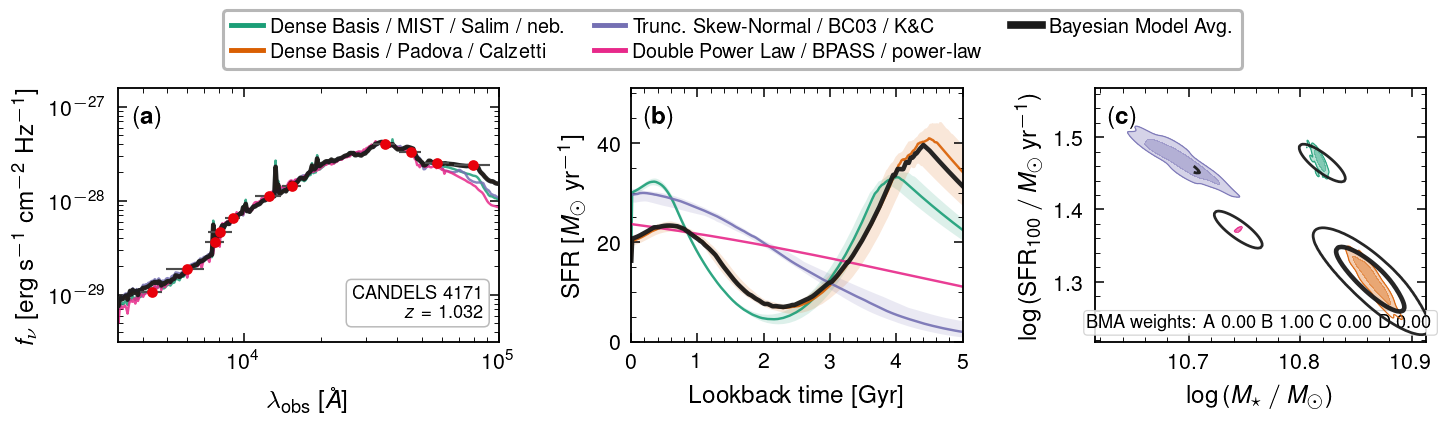

CANDELS 4171: BMA weights  A=0.00  B=1.00  C=0.00  D=0.00


In [11]:
plot_galaxy(4171)

In [12]:
show_timings(4171)

CANDELS 4171  (z = 1.032, 11 bands)
  build (4 models, incl. precompute publish + first compile):   1.0 s
  configuration                       D  fit [s]     log Z
  Dense Basis / MIST / Salim / neb.   8     40.6    -328.8
  Dense Basis / Padova / Calzetti     8     41.5    -170.9
  Trunc. Skew-Normal / BC03 / K\&C    8     36.4    -244.9
  Double Power Law / BPASS / power-law  6     14.8    -461.3
  4-config threaded wall-clock              41.5   (vs 133.3s summed)


### CANDELS 17418

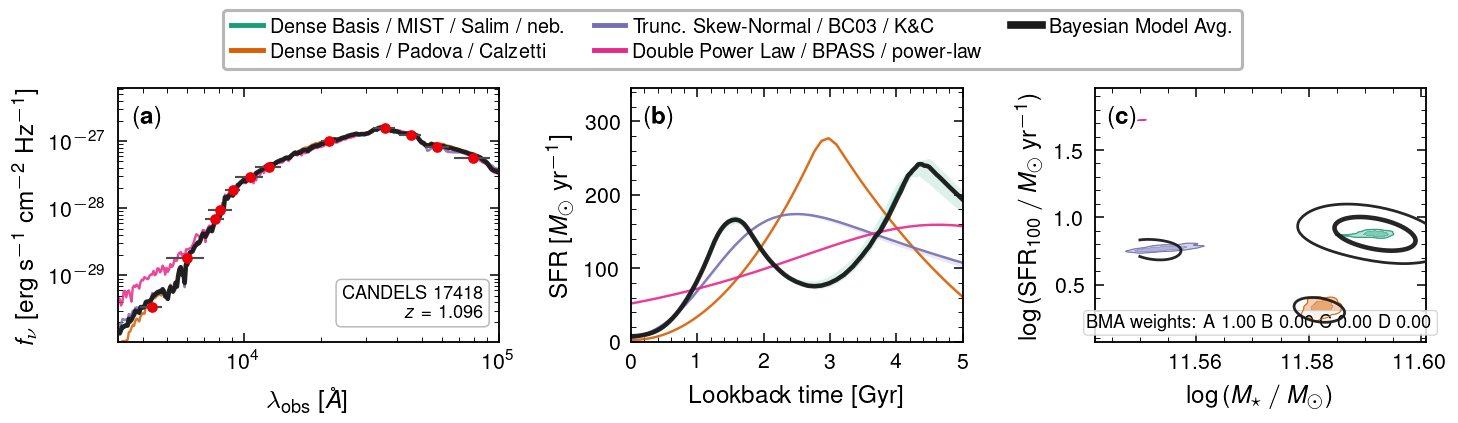

CANDELS 17418: BMA weights  A=1.00  B=0.00  C=0.00  D=0.00


In [13]:
plot_galaxy(17418)

In [14]:
show_timings(17418)

CANDELS 17418  (z = 1.096, 12 bands)
  build (4 models, incl. precompute publish + first compile):   0.8 s
  configuration                       D  fit [s]     log Z
  Dense Basis / MIST / Salim / neb.   8     52.4   -2424.2
  Dense Basis / Padova / Calzetti     8     41.5   -2981.1
  Trunc. Skew-Normal / BC03 / K\&C    8     46.3   -3444.5
  Double Power Law / BPASS / power-law  6     20.7  -14634.0
  4-config threaded wall-clock              52.4   (vs 160.8s summed)


### CANDELS 16435

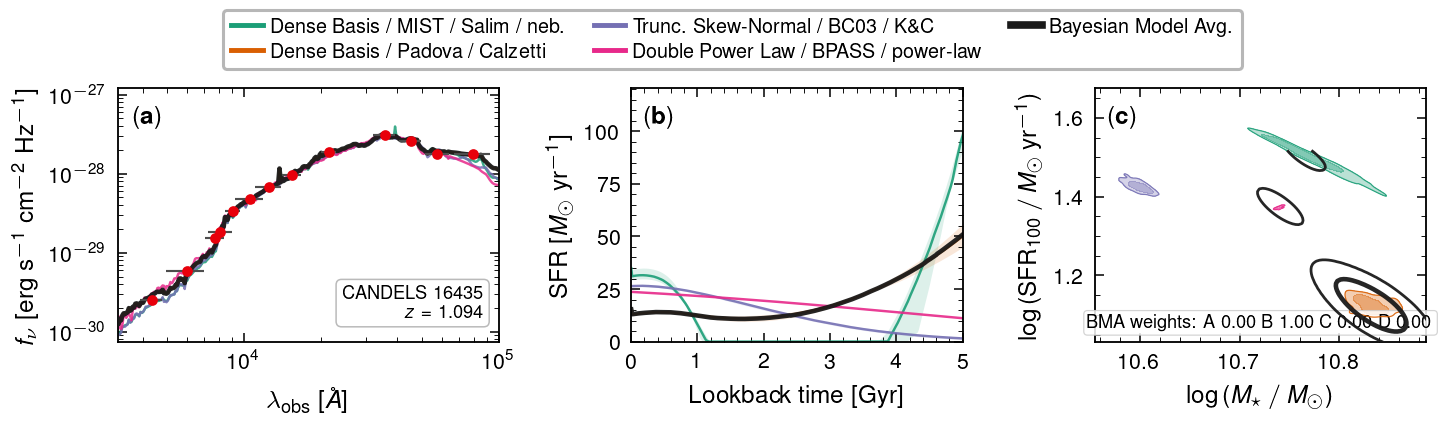

CANDELS 16435: BMA weights  A=0.00  B=1.00  C=0.00  D=0.00


In [15]:
plot_galaxy(16435)

In [16]:
show_timings(16435)

CANDELS 16435  (z = 1.094, 13 bands)
  build (4 models, incl. precompute publish + first compile):   1.0 s
  configuration                       D  fit [s]     log Z
  Dense Basis / MIST / Salim / neb.   8     45.6    -268.2
  Dense Basis / Padova / Calzetti     8     37.2    -170.4
  Trunc. Skew-Normal / BC03 / K\&C    8     38.2    -536.5
  Double Power Law / BPASS / power-law  6     17.9    -541.0
  4-config threaded wall-clock              45.6   (vs 139.0s summed)


### CANDELS 16514

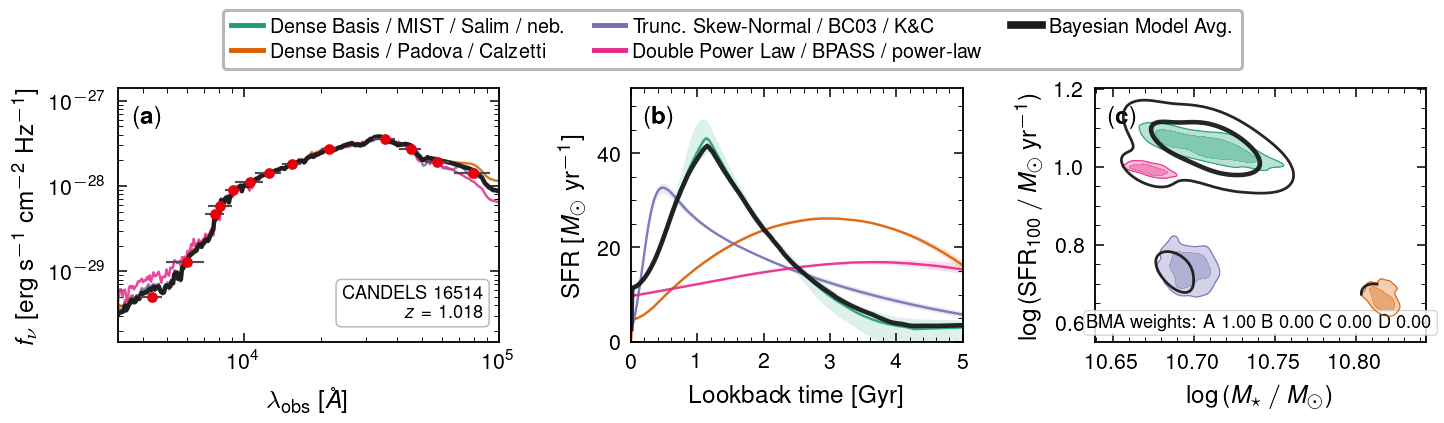

CANDELS 16514: BMA weights  A=1.00  B=0.00  C=0.00  D=0.00


In [17]:
plot_galaxy(16514)

In [18]:
show_timings(16514)

CANDELS 16514  (z = 1.018, 13 bands)
  build (4 models, incl. precompute publish + first compile):   1.0 s
  configuration                       D  fit [s]     log Z
  Dense Basis / MIST / Salim / neb.   8     41.5    -255.8
  Dense Basis / Padova / Calzetti     8     34.3    -272.8
  Trunc. Skew-Normal / BC03 / K\&C    8     48.4    -313.9
  Double Power Law / BPASS / power-law  6     15.0    -807.2
  4-config threaded wall-clock              48.5   (vs 139.3s summed)


### CANDELS 18160

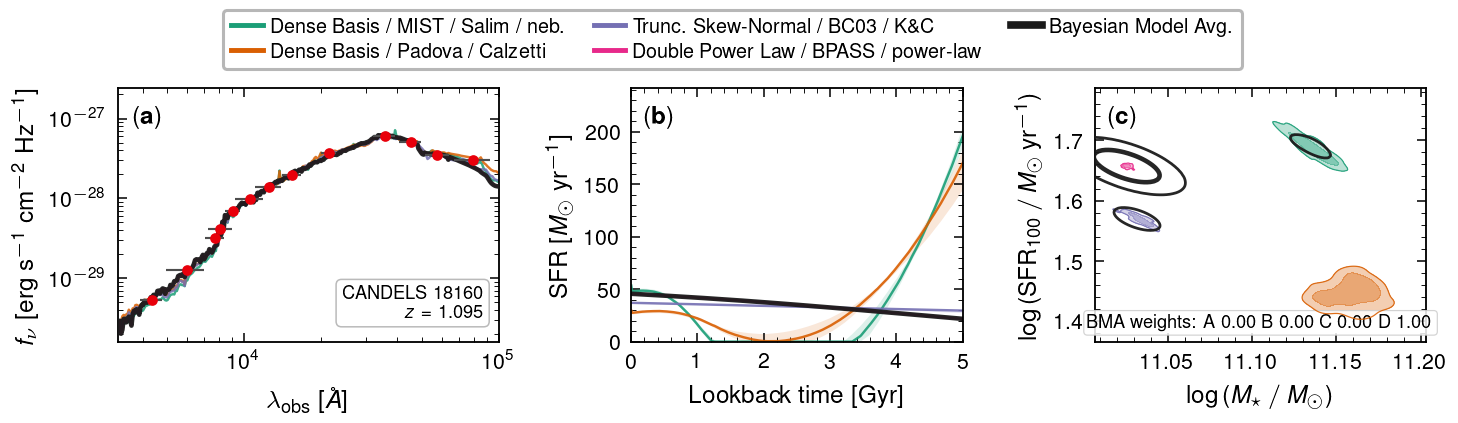

CANDELS 18160: BMA weights  A=0.00  B=0.00  C=0.00  D=1.00


In [19]:
plot_galaxy(18160)

In [20]:
show_timings(18160)

CANDELS 18160  (z = 1.095, 13 bands)
  build (4 models, incl. precompute publish + first compile):   1.0 s
  configuration                       D  fit [s]     log Z
  Dense Basis / MIST / Salim / neb.   8     41.2    -451.9
  Dense Basis / Padova / Calzetti     8     40.4    -614.8
  Trunc. Skew-Normal / BC03 / K\&C    8     28.8    -756.2
  Double Power Law / BPASS / power-law  6     14.2    -340.8
  4-config threaded wall-clock              41.2   (vs 124.5s summed)


### CANDELS 15775

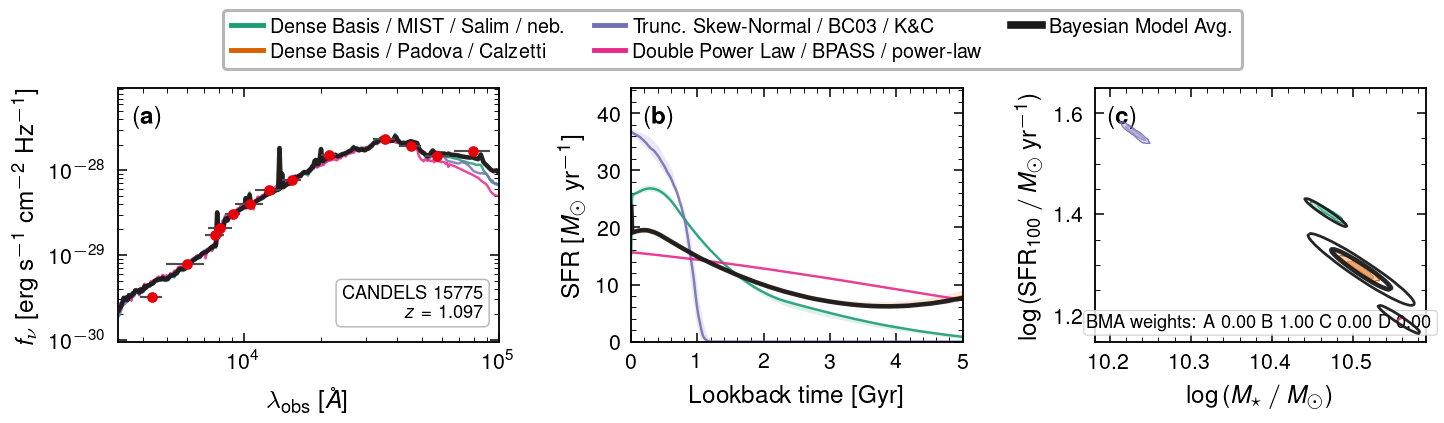

CANDELS 15775: BMA weights  A=0.00  B=1.00  C=0.00  D=0.00


In [21]:
plot_galaxy(15775)

In [22]:
show_timings(15775)

CANDELS 15775  (z = 1.097, 13 bands)
  build (4 models, incl. precompute publish + first compile):   0.8 s
  configuration                       D  fit [s]     log Z
  Dense Basis / MIST / Salim / neb.   8     44.1    -662.4
  Dense Basis / Padova / Calzetti     8     35.7    -471.0
  Trunc. Skew-Normal / BC03 / K\&C    8     44.8   -1575.4
  Double Power Law / BPASS / power-law  6     16.7   -1963.5
  4-config threaded wall-clock              44.9   (vs 141.3s summed)


### CANDELS 13097

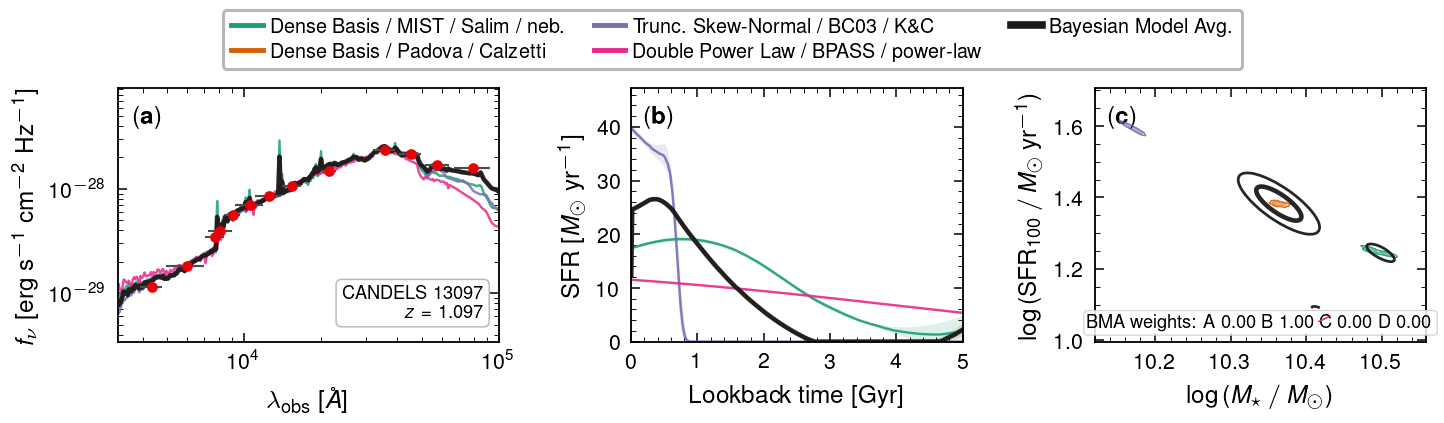

CANDELS 13097: BMA weights  A=0.00  B=1.00  C=0.00  D=0.00


In [23]:
plot_galaxy(13097)

In [24]:
show_timings(13097)

CANDELS 13097  (z = 1.097, 13 bands)
  build (4 models, incl. precompute publish + first compile):   0.8 s
  configuration                       D  fit [s]     log Z
  Dense Basis / MIST / Salim / neb.   8     53.9   -1738.2
  Dense Basis / Padova / Calzetti     8     43.7    -481.1
  Trunc. Skew-Normal / BC03 / K\&C    8     39.4    -728.3
  Double Power Law / BPASS / power-law  6     16.9   -3553.0
  4-config threaded wall-clock              53.9   (vs 153.9s summed)


## 10. Presentation-quality figures

Slide-ready renders of the three panels: larger fonts and panels, thicker
lines, a robust SFH y-limit (so the panel fills), padded $M_\star$–SFR axes,
the BMA shown as an unshaded outline, and the BMA weights annotated on panel
(c). Saved as ``*_pres.png``.

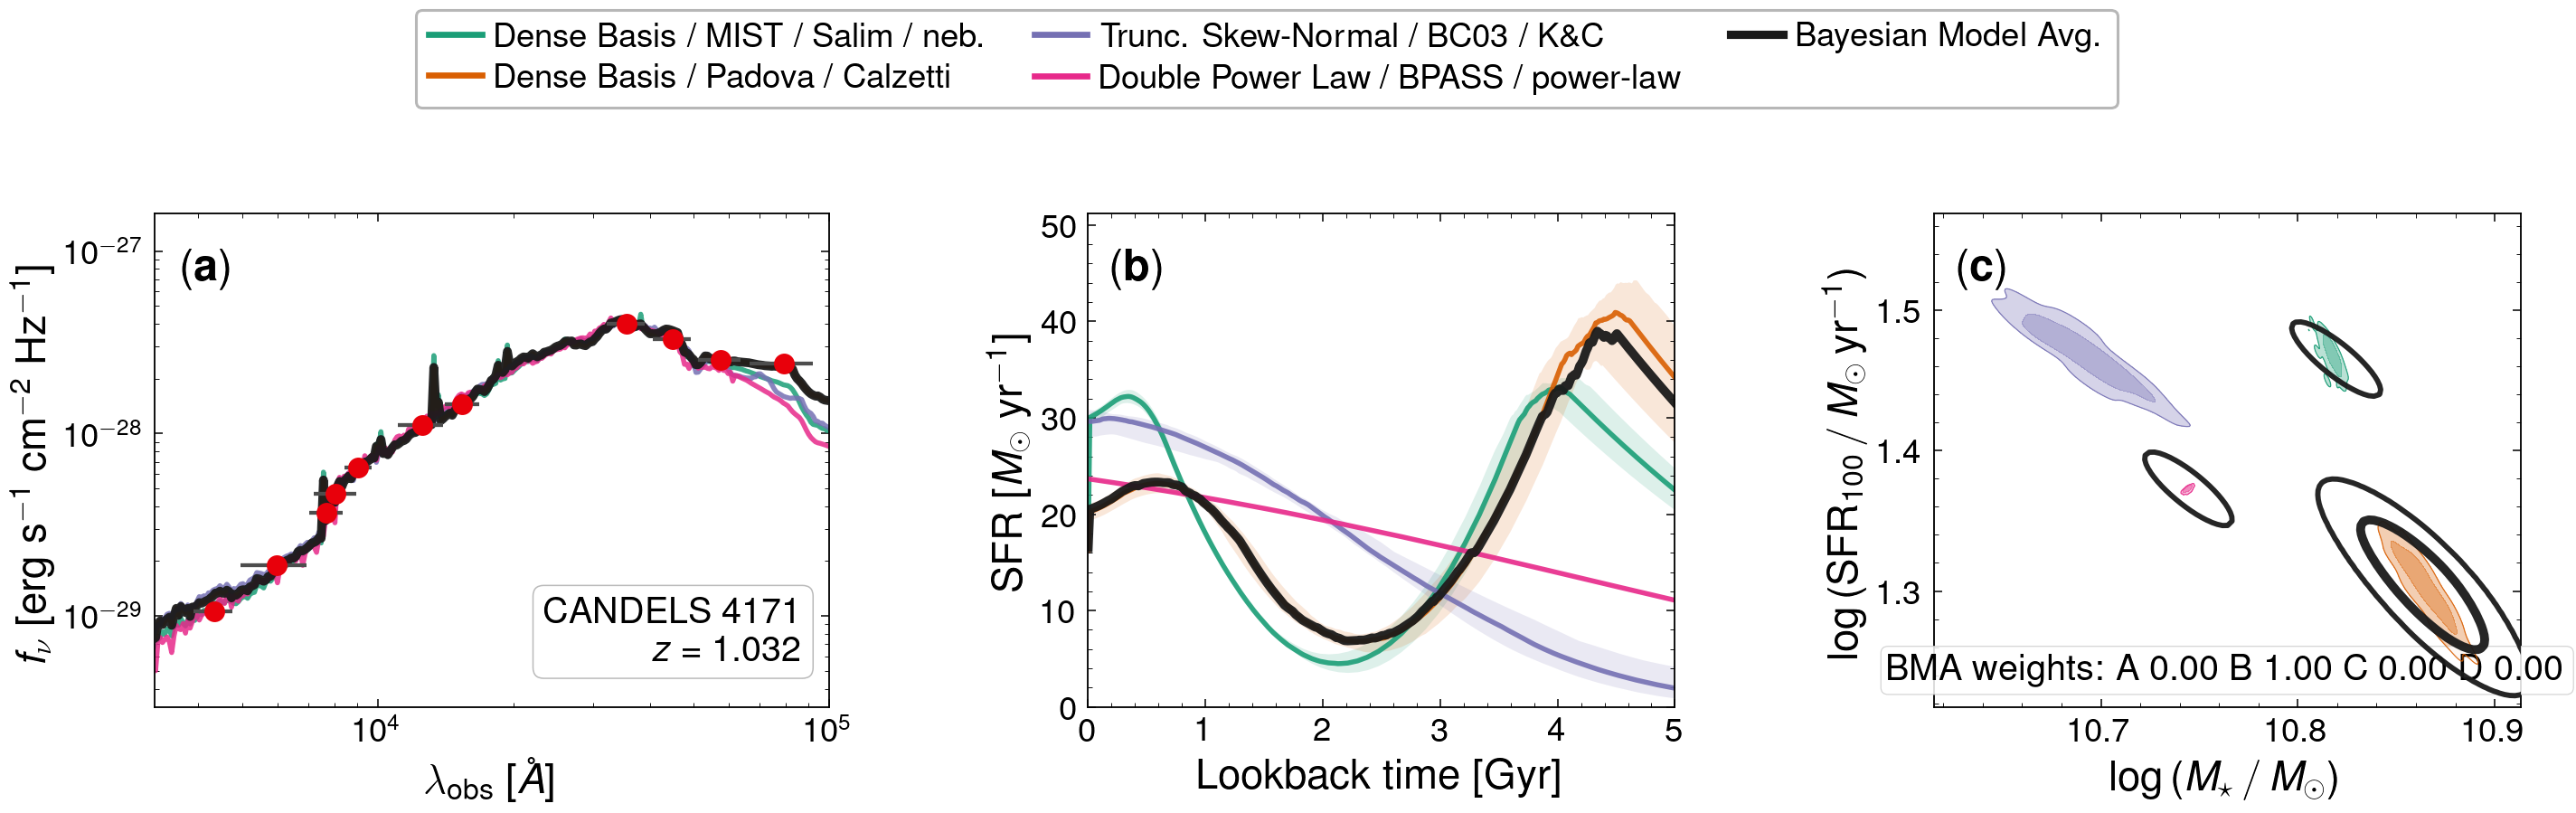

CANDELS 4171: BMA weights  A=0.00  B=1.00  C=0.00  D=0.00


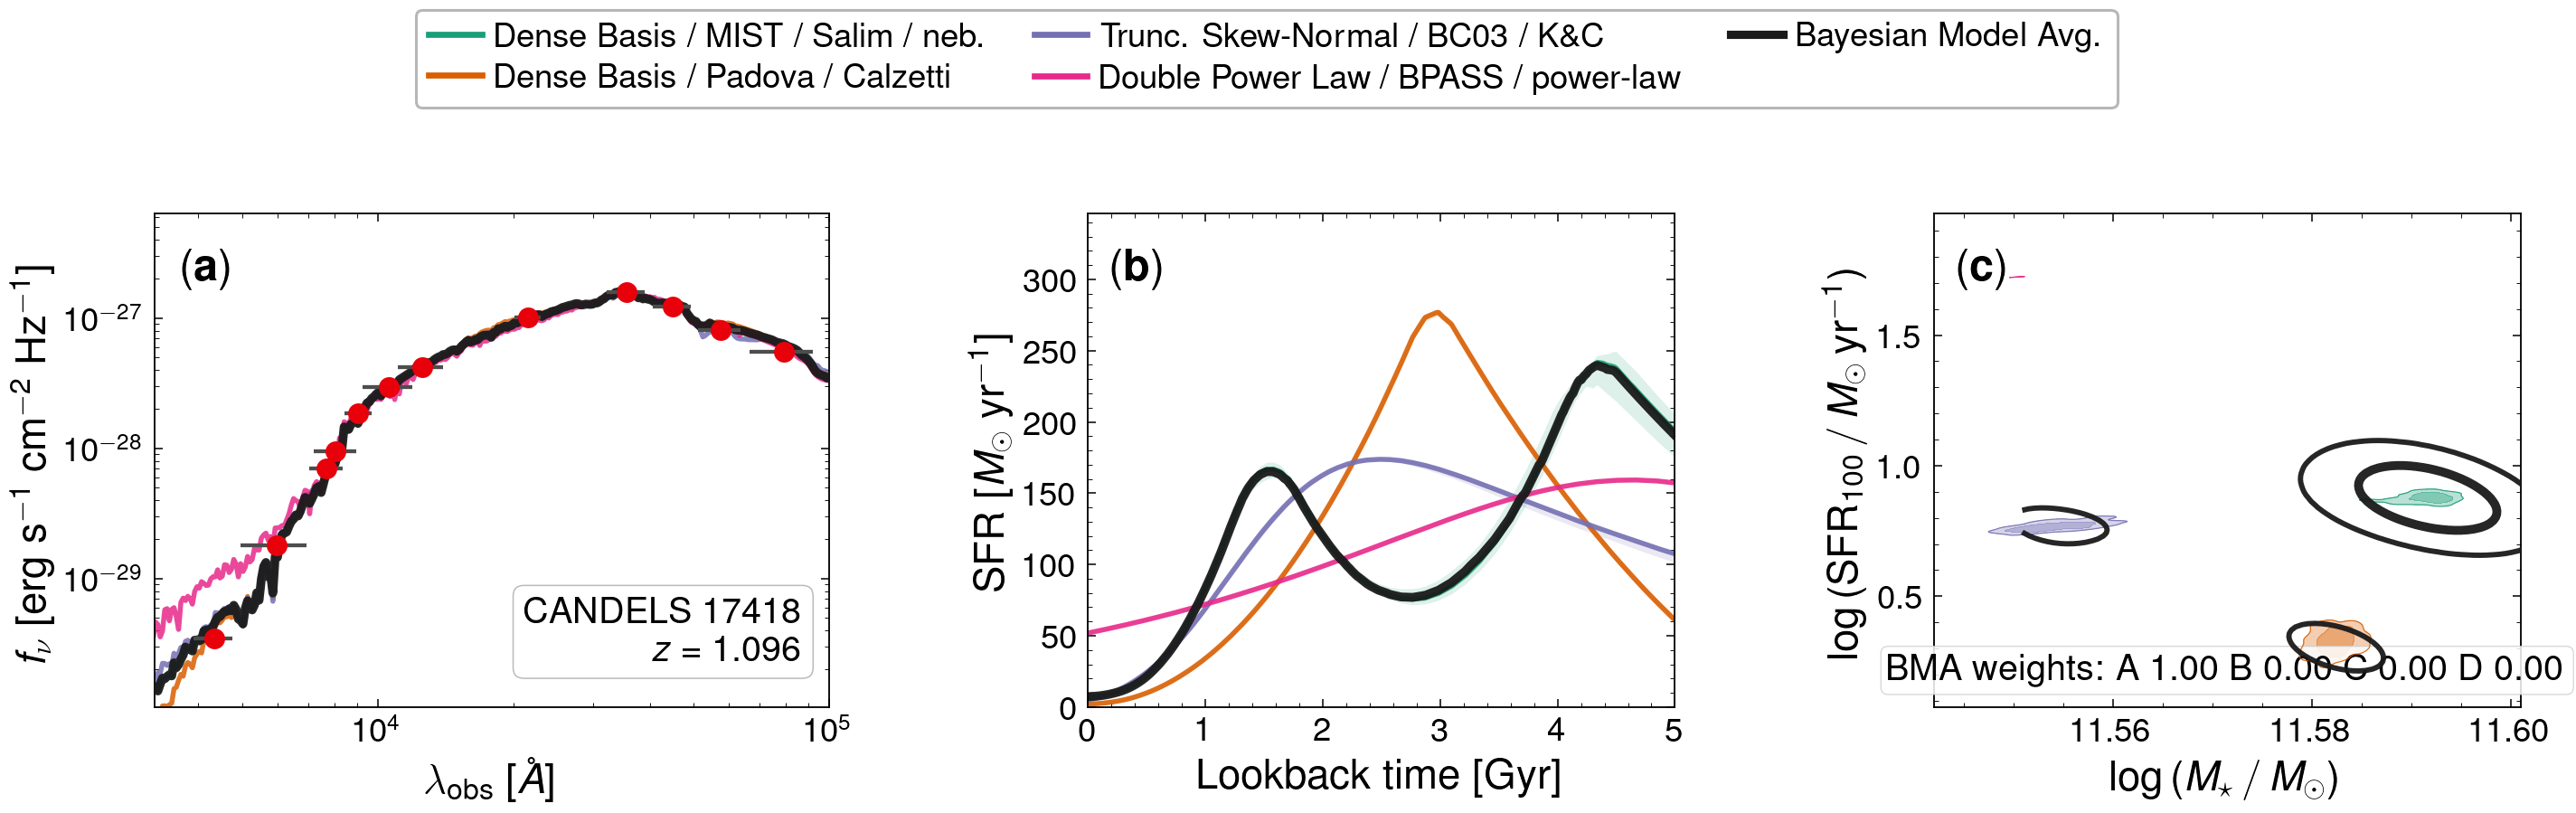

CANDELS 17418: BMA weights  A=1.00  B=0.00  C=0.00  D=0.00


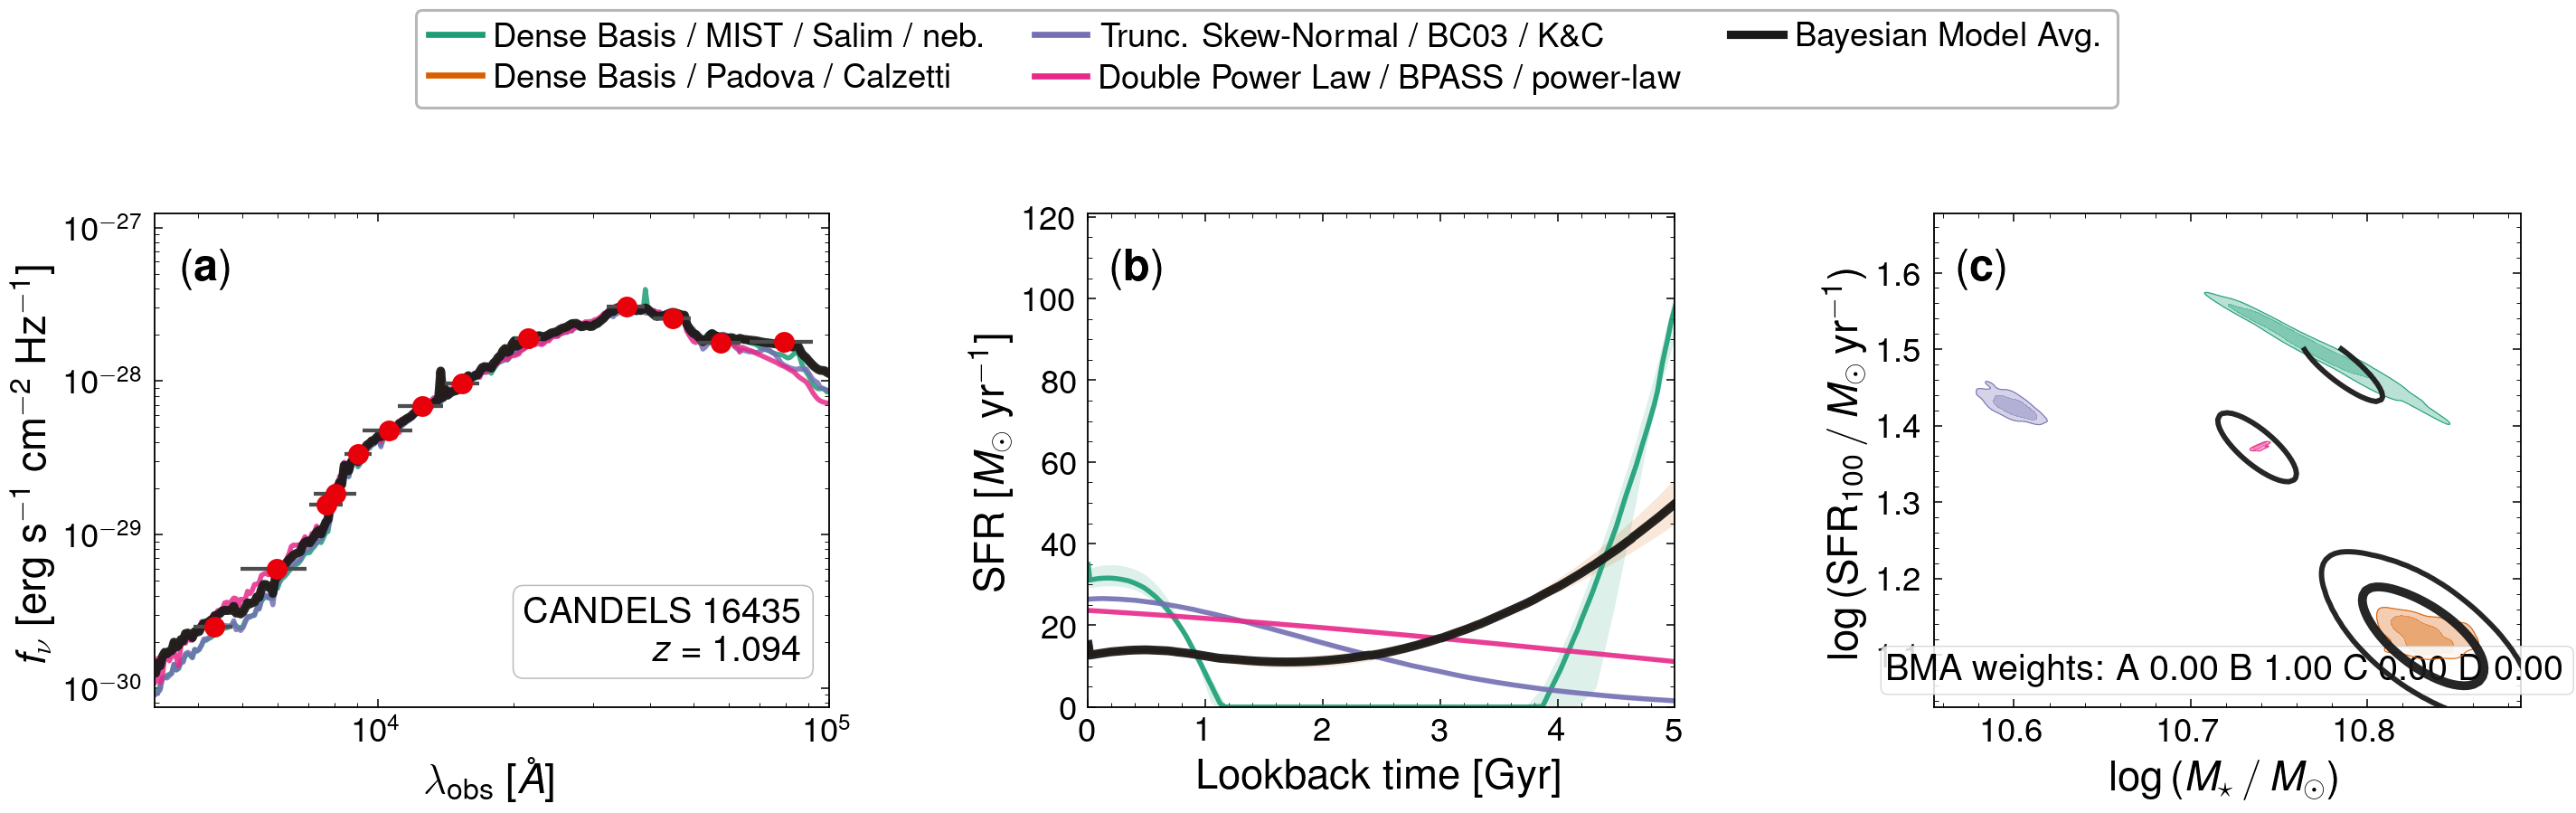

CANDELS 16435: BMA weights  A=0.00  B=1.00  C=0.00  D=0.00


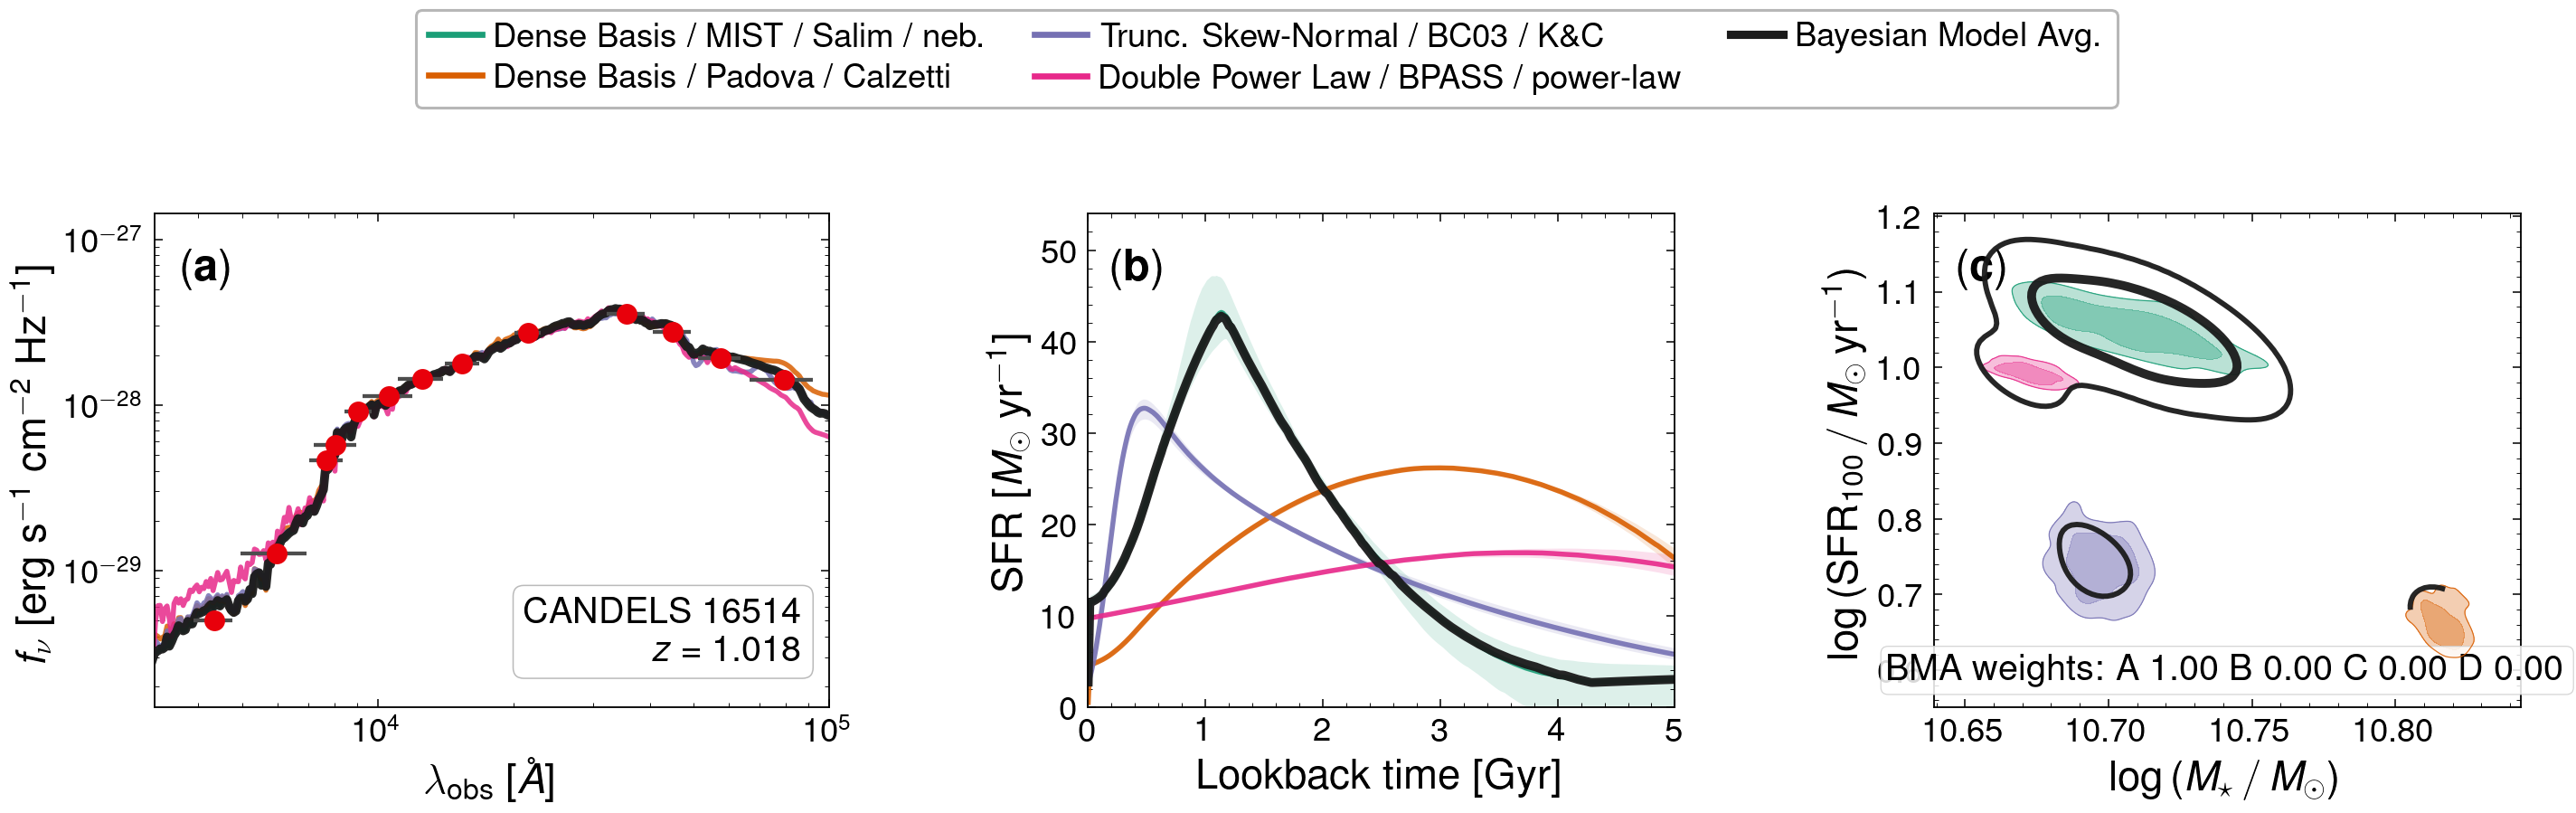

CANDELS 16514: BMA weights  A=1.00  B=0.00  C=0.00  D=0.00


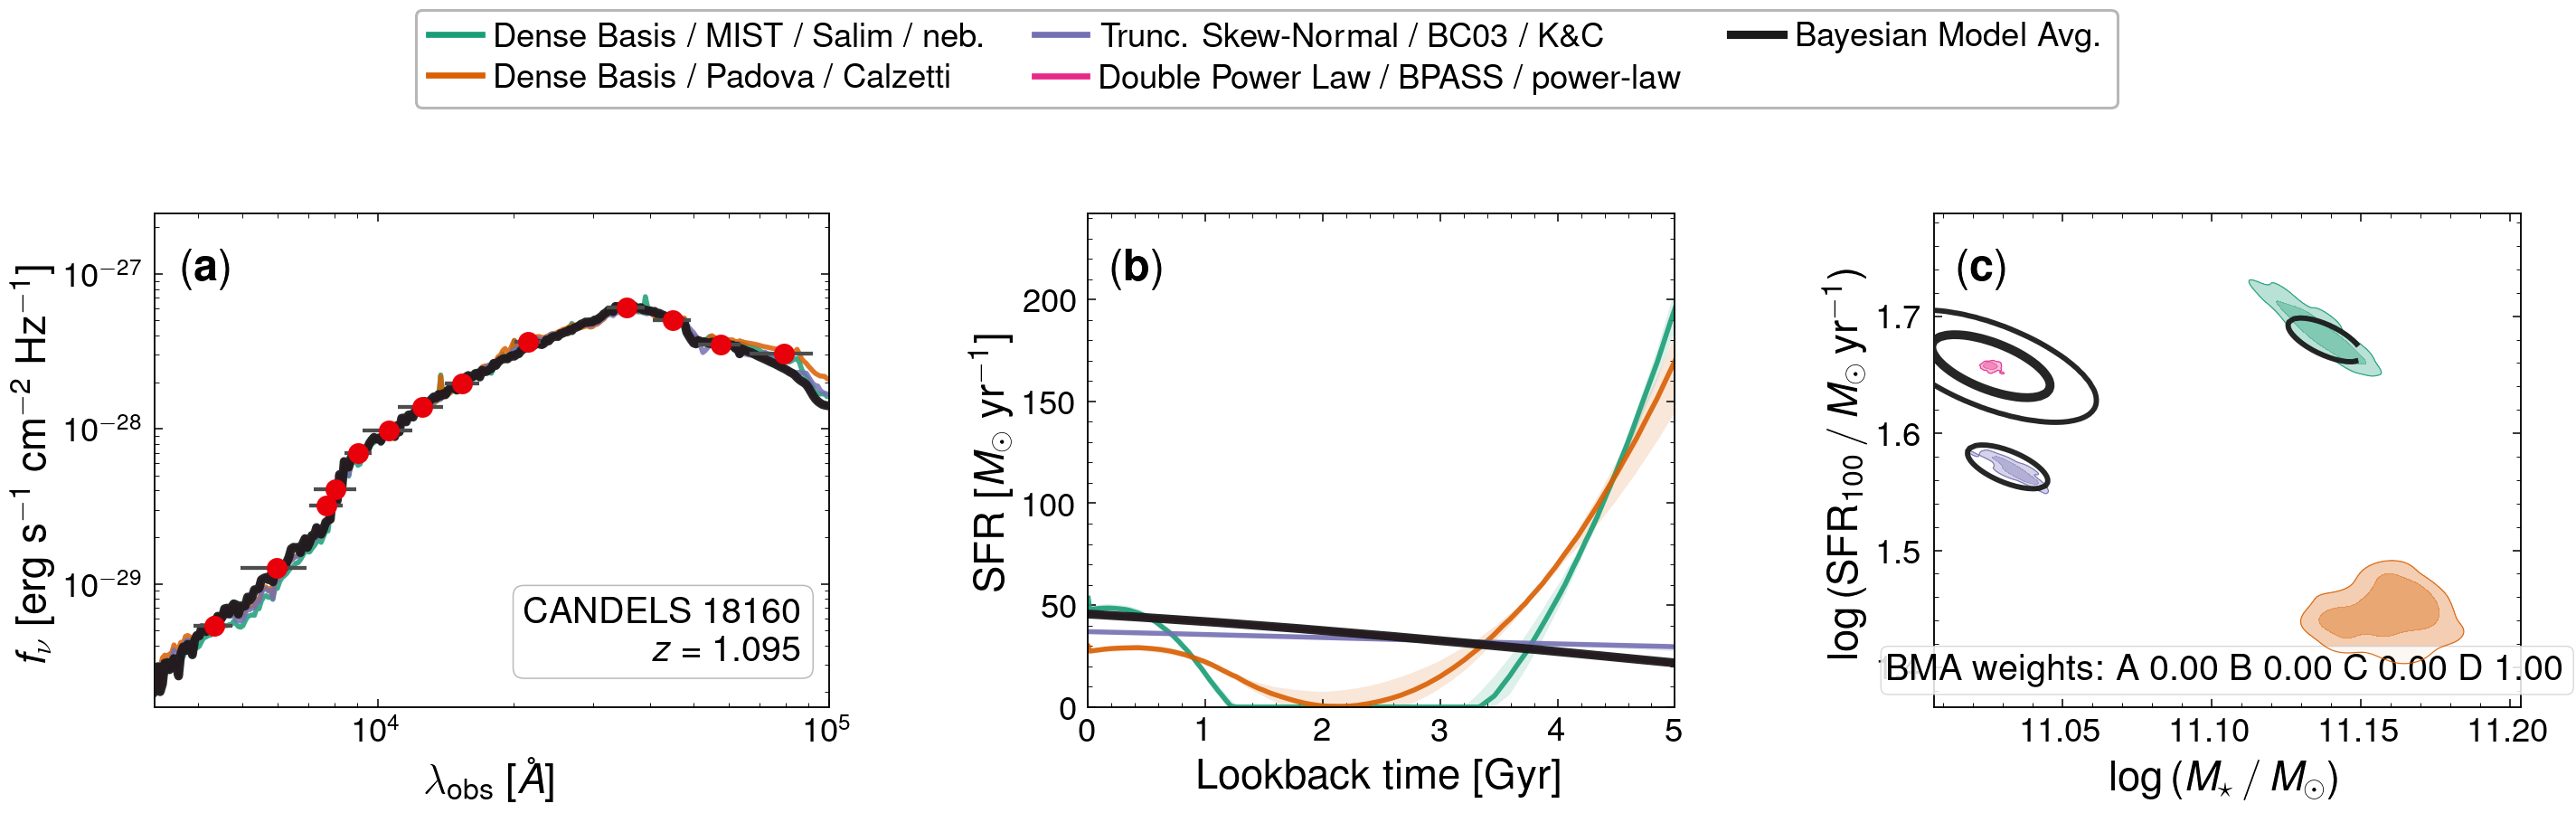

CANDELS 18160: BMA weights  A=0.00  B=0.00  C=0.00  D=1.00


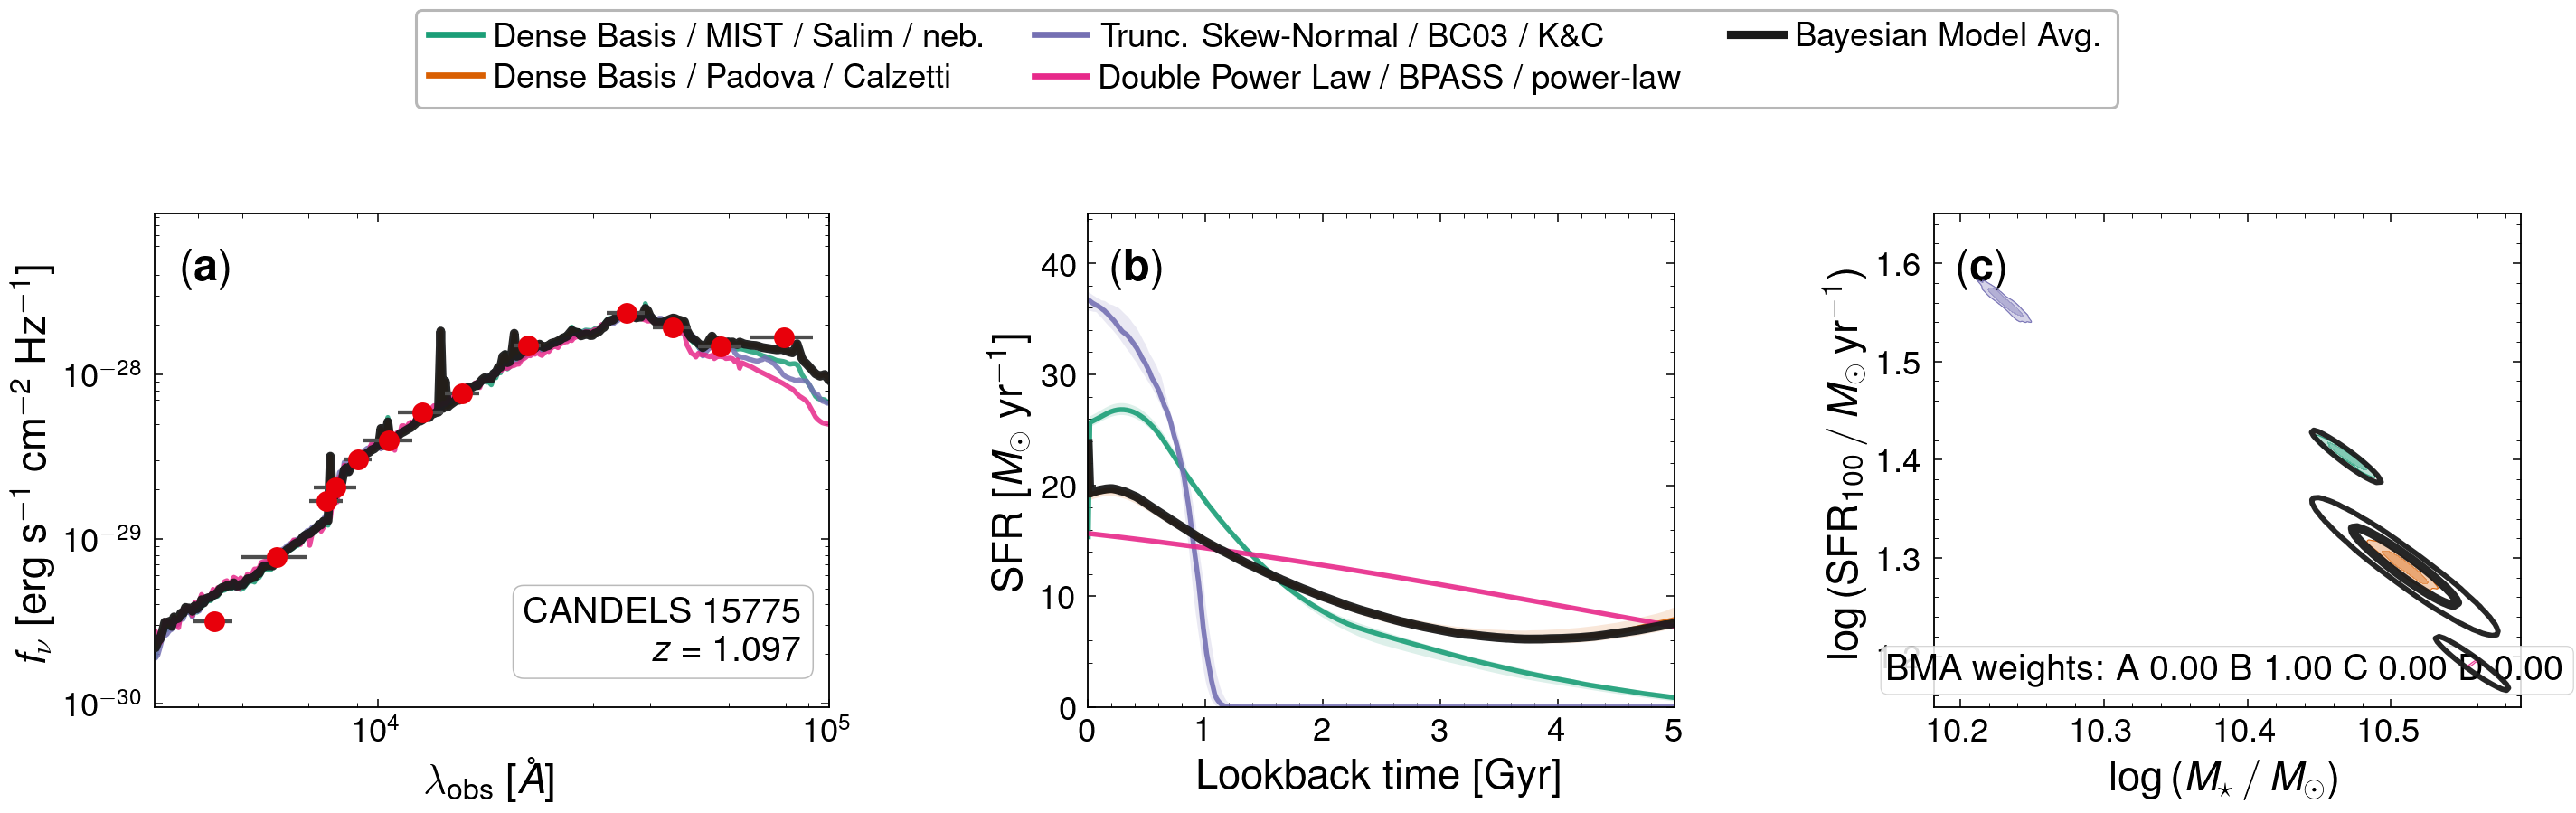

CANDELS 15775: BMA weights  A=0.00  B=1.00  C=0.00  D=0.00


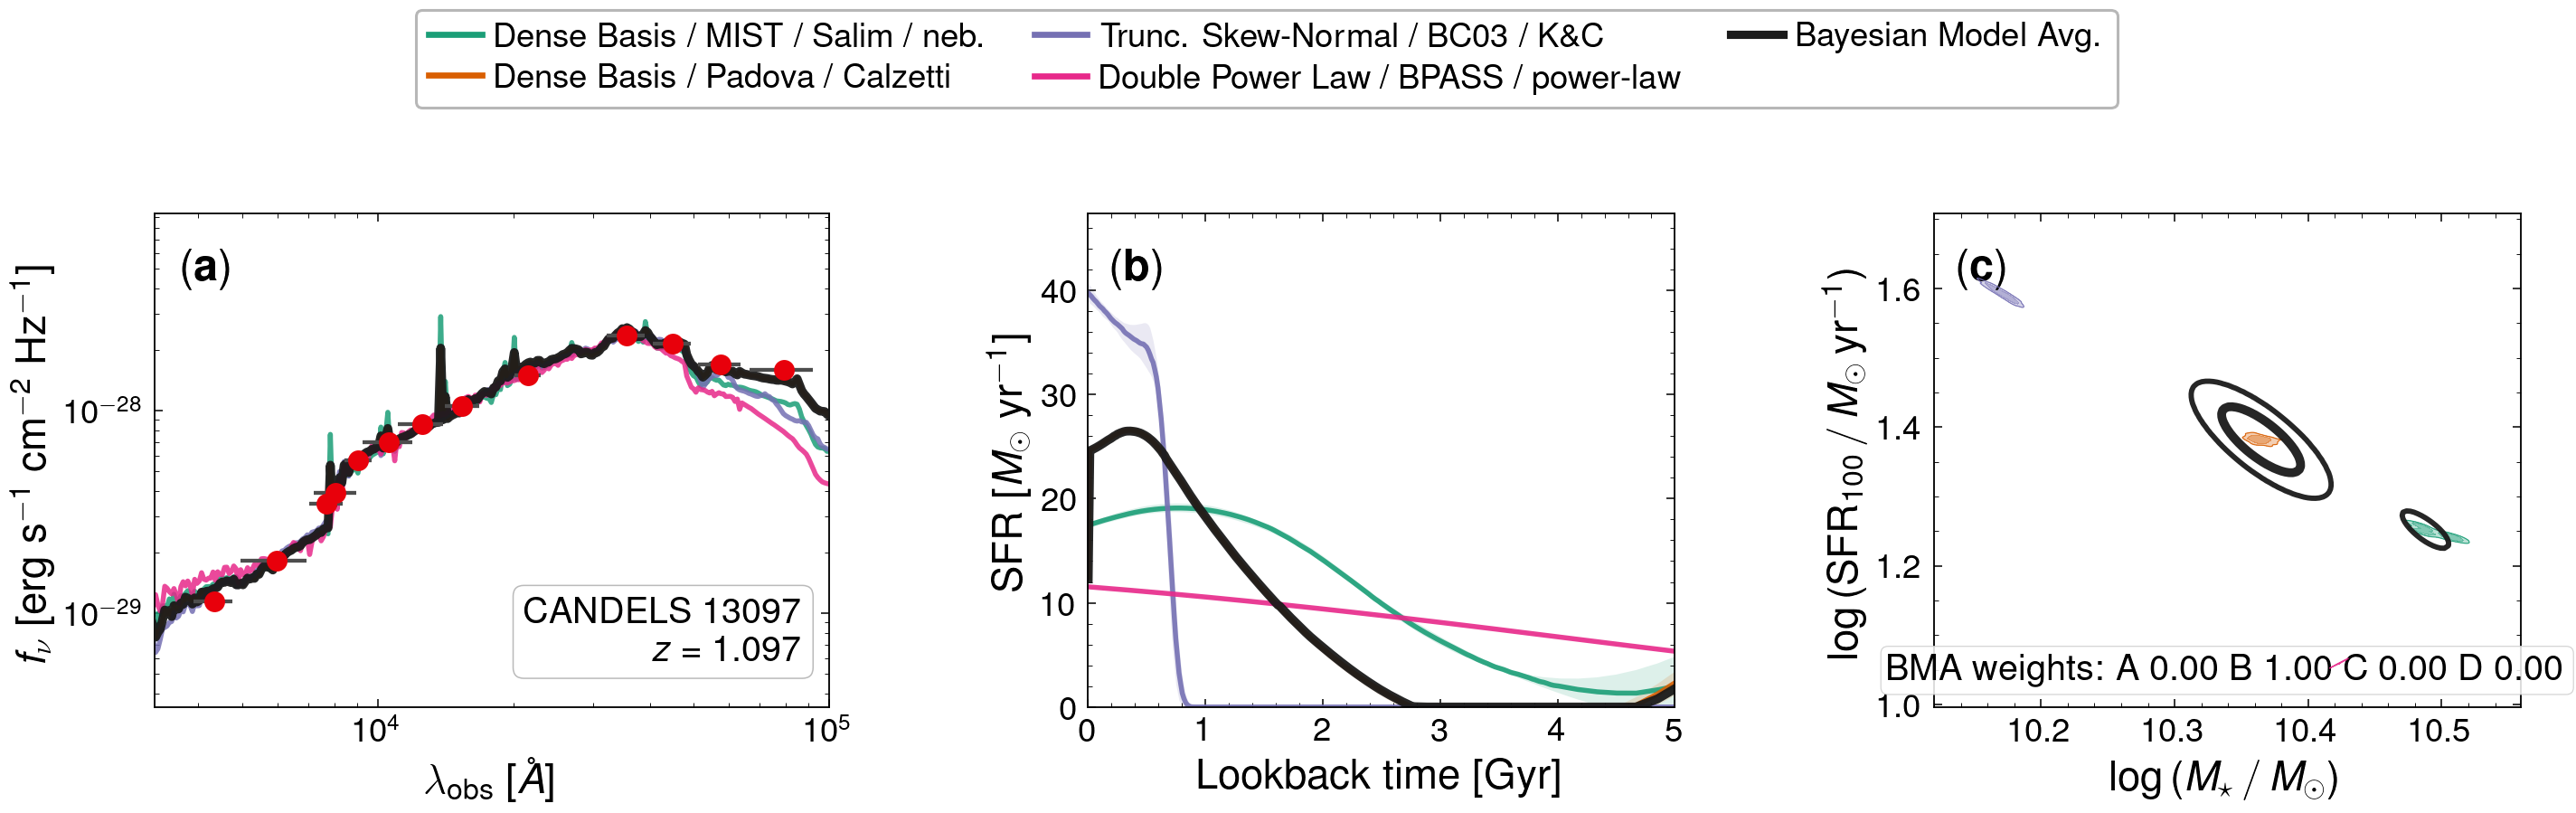

CANDELS 13097: BMA weights  A=0.00  B=1.00  C=0.00  D=0.00


In [25]:
for _gid in GAL_IDS:
    plot_galaxy(_gid, presentation=True)

## 11. Genuine model averaging with an error floor

Every galaxy above collapses onto a single configuration: with the raw
catalogue errors (~1–2% at this S/N) the evidence is overwhelmingly decisive,
so the BMA *is* the single best model. That is honest, but it hides what BMA is
for.

Catalogue errors are **statistical only** — they omit systematics
(zero-points, aperture matching, filter curves) and, crucially for model
comparison, **template imperfection** (the SPS models are good to only a few
percent). Standard practice (EAZY/FAST template-error + ~5% systematic,
Prospector noise inflation, CIGALE per-band floors) is to add a fractional
**error floor in quadrature to the uncertainty that enters the likelihood**,

$$\sigma_\mathrm{eff}^2 = \sigma_\mathrm{cat}^2 + (f_\mathrm{floor}\,f_\nu)^2 .$$

With a 10% floor the per-band $\chi^2$ no longer explodes, the evidences become
commensurable, and the BMA spreads its weight across configurations — genuine
averaging. (The cost is broader, more overlapping $M_\star$–SFR clusters: the
floor trades the artificially tight per-model posteriors for honest ones.)

In [26]:
ERROR_FLOOR = 0.10  # 10% systematic + template-error floor, added in quadrature
FLOOR_IDS = [18160, 17418]  # picked (by a weight-entropy screen) to show real averaging
galaxies_floor = {}
for gal_idx in [int(np.where(ids == g)[0][0]) for g in FLOOR_IDS]:
    gal_id, z, names, fnu, sigma_cat = extract_photometry(gal_idx)
    sigma = jnp.sqrt(sigma_cat**2 + (ERROR_FLOOR * fnu) ** 2)  # inflated uncertainty
    obs = Observation(photometry=Photometry.from_names(names))
    models = build_configs(z, obs)
    posteriors = {}
    with ThreadPoolExecutor(max_workers=len(CONFIG_ORDER)) as ex:
        futs = [
            ex.submit(fit_one, models[cfg], fnu, sigma, gal_id=gal_id, cfg=cfg, salt="floor")
            for cfg in CONFIG_ORDER
        ]
        for fut in futs:
            cfg, post, _dt = fut.result()
            posteriors[cfg] = post
    g = dict(z=z, names=names, fnu=np.asarray(fnu), sigma=np.asarray(sigma),
             models=models, posteriors=posteriors, build_s=0.0,
             fit_timings={c: 0.0 for c in CONFIG_ORDER})  # fmt: skip
    g["weights"] = bma_weights(posteriors)
    g["spec"], g["sfh"], g["props"] = collect_predictions(g)
    galaxies_floor[gal_id] = g
    wstr = "  ".join(f"{c}={x:.2f}" for c, x in zip(CONFIG_ORDER, g["weights"]))
    print(f"CANDELS {gal_id} (floor {ERROR_FLOOR:.0%}):  BMA weights  {wstr}")

W0605 23:38:58.196605 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 23:38:58.689035 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:38:58.772675 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:38:58.777312 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:38:58.781455 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:38:58.785666 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:38:58.820054 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 23:38:58.981876 3737088 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 23:39:00.290021 3737090 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:39:00.293675 3737090 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:39:00.323309 3737090 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:39:00.339575 3737090 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:39:00.348949 3737090 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:39:00.357890 3737090 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:39:00.388104 3737090 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:39:00.397593 3737090 pjrt_executable.cc:638] Assume v

W0605 23:39:00.767421 3737090 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:39:00.861233 3737090 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:39:00.867286 3737090 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:39:00.879424 3737090 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:39:00.899911 3737090 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:39:00.905505 3737090 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 23:39:00.922637 3737090 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

W0605 23:40:41.339662 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 23:40:41.822432 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 23:40:42.094887 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 23:40:42.318107 3718609 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


CANDELS 17418 (floor 10%):  BMA weights  A=0.62  B=0.26  C=0.12  D=0.00


### CANDELS 18160 — 10% error floor (BMA averages four configurations)

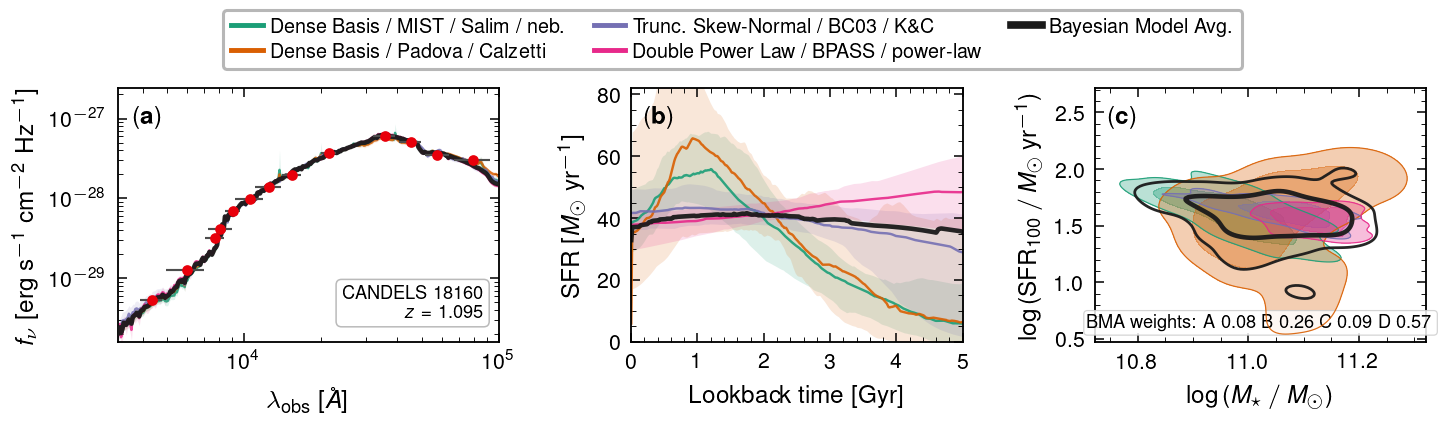

CANDELS 18160: BMA weights  A=0.08  B=0.26  C=0.09  D=0.57


In [27]:
plot_galaxy(18160, source=galaxies_floor, tag="_floor")

### CANDELS 17418 — 10% error floor (BMA averages three configurations)

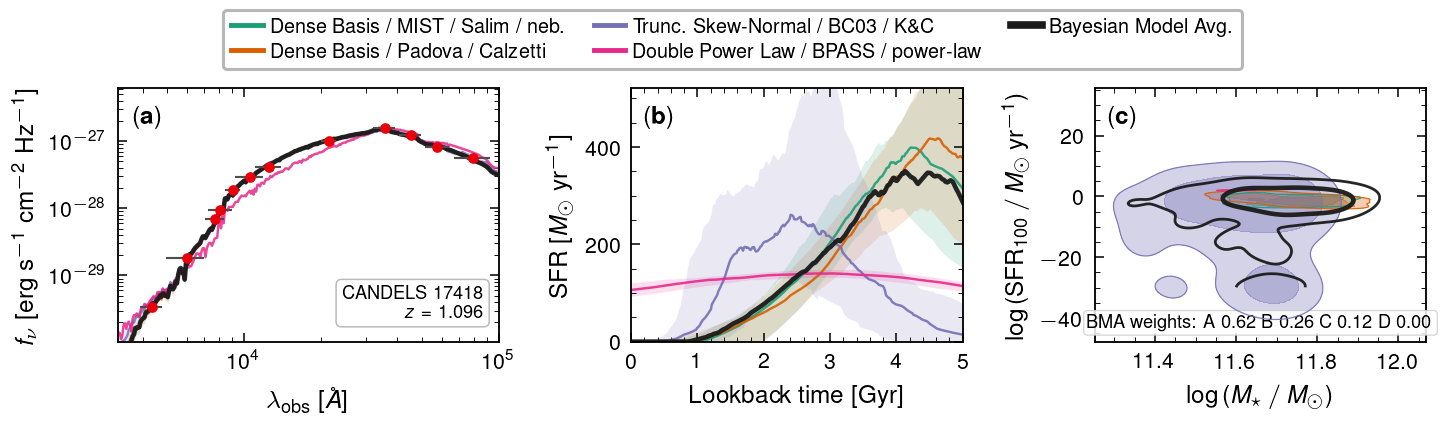

CANDELS 17418: BMA weights  A=0.62  B=0.26  C=0.12  D=0.00


In [28]:
plot_galaxy(17418, source=galaxies_floor, tag="_floor")

## 12. Takeaways

- **The evidence picks favourites.** The BMA weights are rarely uniform — one
  or two configurations usually dominate $\log Z$, and the average is pulled
  toward them while still retaining the others' spread.
- **The models genuinely disagree.** Panel (c) shows four tight but
  *separated* $M_\star$–SFR clusters: swapping SSP library, SFH family, or dust
  law moves the inferred stellar mass by a few tenths of a dex even at fixed
  photometry. That systematic spread is exactly what BMA exposes.
- **Same public surface throughout.** Every model came from
  `SEDModel.build(...)` with the nested-dict grammar; the only knob that
  changed for speed was `approx=WavePrecomp()`. Inference was the one-liner
  `Fitter(model, data, noise).run("nss", ...)`, whose `log_evidence` is what
  makes the averaging principled.
- **The error budget decides whether you average.** With raw catalogue errors
  the evidence collapses onto one model; adding a realistic ~10% systematic
  floor (§11) makes the evidences commensurable and the BMA genuinely averages.
  Whether to average — or to trust the single best model — is set by how well
  you believe your photometry *and templates*, not by the fitter.